In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import geopandas as gpd
from shapely.geometry import Point

import folium

# Spatial statistics
from libpysal.weights import KNN
from esda.moran import Moran
from esda.getisord import G

# Clustering
from sklearn.cluster import DBSCAN

# Spatial regression
from spreg import ML_Lag

# Kriging
!pip install pykrige
from pykrige.ok import OrdinaryKriging

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
pollution = pd.read_csv("/content/drive/MyDrive/spatial_project/india_city_aqi_2015_2023.csv")
weather = pd.read_csv("/content/drive/MyDrive/spatial_project/weather.csv")
coords = pd.read_csv("/content/drive/MyDrive/spatial_project/india_cities.csv")

In [ ]:
print("Pollution DataFrame Info:")
pollution.info()
print("\nPollution DataFrame Head:")
display(pollution.head())

print("\nWeather DataFrame Info:")
weather.info()
print("\nWeather DataFrame Head:")
display(weather.head())

Pollution DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32870 entries, 0 to 32869
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   city          32870 non-null  object 
 1   date          32870 non-null  object 
 2   pm25          32870 non-null  float64
 3   pm10          32870 non-null  float64
 4   no2           32870 non-null  float64
 5   so2           32870 non-null  float64
 6   co            32870 non-null  float64
 7   o3            32870 non-null  float64
 8   aqi           32870 non-null  int64  
 9   aqi_category  32870 non-null  object 
dtypes: float64(6), int64(1), object(3)
memory usage: 2.5+ MB

Pollution DataFrame Head:


,city,date,pm25,pm10,no2,so2,co,o3,aqi,aqi_category
0,Delhi,2015-01-01,99.868566,147.103280,49.715328,19.615149,0.729754,46.487946,103,Moderate
1,Delhi,2015-01-02,143.168513,208.517207,32.957884,14.712800,0.660975,43.014054,141,Moderate
2,Delhi,2015-01-03,89.678491,101.412886,14.126233,9.188562,0.496151,54.713710,82,Satisfactory
3,Delhi,2015-01-04,43.679037,65.432963,61.984732,10.871118,0.820258,28.628777,50,Good
4,Delhi,2015-01-05,58.224691,110.443143,22.735096,13.878490,0.619808,45.624594,69,Satisfactory



Weather DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 42 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   country                       572 non-null    object 
 1   location_name                 572 non-null    object 
 2   region                        572 non-null    object 
 3   latitude                      572 non-null    float64
 4   longitude                     572 non-null    float64
 5   timezone                      572 non-null    object 
 6   last_updated_epoch            572 non-null    int64  
 7   last_updated                  572 non-null    object 
 8   temperature_celsius           572 non-null    float64
 9   temperature_fahrenheit        572 non-null    float64
 10  condition_text                572 non-null    object 
 11  wind_mph                      572 non-null    float64
 12  wind_kph                      572 non-n

,country,location_name,region,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,India,Ashoknagar,Madhya Pradesh,24.57,77.72,Asia/Kolkata,1693286100,2023-08-29 10:45,27.5,81.5,...,12.6,18.5,1,2,05:59 AM,06:41 PM,05:42 PM,03:38 AM,Waxing Gibbous,93
1,India,Raisen,Madhya Pradesh,23.33,77.80,Asia/Kolkata,1693286100,2023-08-29 10:45,27.5,81.5,...,10.7,14.2,1,1,06:00 AM,06:40 PM,05:39 PM,03:41 AM,Waxing Gibbous,93
2,India,Chhindwara,Madhya Pradesh,22.07,78.93,Asia/Kolkata,1693286100,2023-08-29 10:45,26.3,79.3,...,16.8,20.7,2,2,05:56 AM,06:34 PM,05:32 PM,03:39 AM,Waxing Gibbous,93
3,India,Betul,Madhya Pradesh,21.86,77.93,Asia/Kolkata,1693286100,2023-08-29 10:45,25.6,78.1,...,4.9,6.6,1,1,06:00 AM,06:38 PM,05:36 PM,03:43 AM,Waxing Gibbous,93
4,India,Hoshangabad,Madhya Pradesh,22.75,77.72,Asia/Kolkata,1693286100,2023-08-29 10:45,27.2,81.0,...,11.4,14.8,1,1,06:01 AM,06:39 PM,05:38 PM,03:42 AM,Waxing Gibbous,93


In [ ]:
print("\nCoords DataFrame Info:")
coords.info()
print("\nCoords DataFrame Head:")
display(coords.head())


Coords DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 557957 entries, 0 to 557956
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   name        557956 non-null  object 
 1   latitude    557957 non-null  float64
 2   longitude   557957 non-null  float64
 3   population  557957 non-null  int64  
dtypes: float64(2), int64(1), object(1)
memory usage: 17.0+ MB

Coords DataFrame Head:


,name,latitude,longitude,population
0,Tithwāl,34.39351,73.77416,0
1,Thruti,33.52682,74.15939,0
2,Thang,34.92740,76.79336,1622
3,Pūnch,33.77033,74.09254,28197
4,Mahmūd Khāneke,30.66711,74.21704,0


In [ ]:
# Standardize city names in pollution and coords for consistent merging
pollution['city'] = pollution['city'].str.lower().str.strip()
coords['name'] = coords['name'].str.lower().str.strip()

# Rename 'name' column in coords to 'city' for merging
coords_for_merge = coords.rename(columns={'name': 'city'})

# Select only the relevant columns from coords_for_merge for merging (city, latitude, longitude)
city_coords_new = coords_for_merge[['city', 'latitude', 'longitude']].drop_duplicates(subset=['city'])

# Merge coordinates into the pollution DataFrame, overwriting previous attempts
pollution_with_coords = pd.merge(pollution, city_coords_new, on='city', how='left')

print(f"Number of pollution records after new coordinate merge: {len(pollution_with_coords)}")
print(f"Number of unique cities in pollution dataset: {pollution['city'].nunique()}")
print(f"Number of unique cities with coordinates in new coords dataset: {city_coords_new['city'].nunique()}")

# Recheck for cities in pollution data that still have missing coordinates
missing_coords_cities_final = pollution_with_coords[pollution_with_coords['latitude'].isnull()]['city'].unique()

if len(missing_coords_cities_final) > 0:
    print(f"\nDetected {len(missing_coords_cities_final)} cities in the pollution dataset that still have missing coordinates after using the new source. Examples: {missing_coords_cities_final[:5]}")
else:
    print("\nAll cities in the pollution dataset now have coordinates from the new source.")

display(pollution_with_coords.head())

Number of pollution records after new coordinate merge: 32870
Number of unique cities in pollution dataset: 10
Number of unique cities with coordinates in new coords dataset: 355525

All cities in the pollution dataset now have coordinates from the new source.


,city,date,pm25,pm10,no2,so2,co,o3,aqi,aqi_category,latitude,longitude
0,delhi,2015-01-01,99.868566,147.103280,49.715328,19.615149,0.729754,46.487946,103,Moderate,28.65195,77.23149
1,delhi,2015-01-02,143.168513,208.517207,32.957884,14.712800,0.660975,43.014054,141,Moderate,28.65195,77.23149
2,delhi,2015-01-03,89.678491,101.412886,14.126233,9.188562,0.496151,54.713710,82,Satisfactory,28.65195,77.23149
3,delhi,2015-01-04,43.679037,65.432963,61.984732,10.871118,0.820258,28.628777,50,Good,28.65195,77.23149
4,delhi,2015-01-05,58.224691,110.443143,22.735096,13.878490,0.619808,45.624594,69,Satisfactory,28.65195,77.23149


In [ ]:
import pandas as pd

# Standardize city names for consistent merging
pollution['city'] = pollution['city'].str.lower().str.strip()
weather['location_name'] = weather['location_name'].str.lower().str.strip()

# Extract unique city coordinates from the weather data
# Since the weather data contains a single date, each location_name should have unique coordinates.
city_coords = weather[['location_name', 'latitude', 'longitude']].drop_duplicates(subset=['location_name'])
city_coords = city_coords.rename(columns={'location_name': 'city'})

# NOTE: The following line was overwriting the pollution_with_coords generated in cell 6d2506ed
# which had coordinates for all cities from the comprehensive 'coords' dataset.
# We will avoid overwriting it here to maintain the full set of coordinates.
# pollution_with_coords = pd.merge(pollution, city_coords, on='city', how='left')

# Instead, let's just analyze the potential merge without overwriting the main DataFrame
pollution_with_weather_coords_check = pd.merge(pollution, city_coords, on='city', how='left')

print(f"Number of pollution records before coordinate merge: {len(pollution)}")
print(f"Number of pollution records after coordinate merge (with weather coords): {len(pollution_with_weather_coords_check)}")
print(f"Number of unique cities in pollution dataset: {pollution['city'].nunique()}")
print(f"Number of unique locations with coordinates in weather dataset: {city_coords['city'].nunique()}")

# Check for cities in pollution data that did not get coordinates from weather dataset
missing_coords_cities = pollution_with_weather_coords_check[pollution_with_weather_coords_check['latitude'].isnull()]['city'].unique()

if len(missing_coords_cities) > 0:
    print(f"\nDetected {len(missing_coords_cities)} cities in the pollution dataset that do not have matching coordinates in the weather dataset. Examples: {missing_coords_cities[:5]}")
else:
    print("\nAll cities in the pollution dataset found matching coordinates in the weather dataset.")

# Displaying the head of this temporary dataframe for verification
# display(pollution_with_weather_coords_check.head())

# Ensure pollution_with_coords used in subsequent cells retains ALL coordinates from 6d2506ed
# This means we rely on the 'pollution_with_coords' from cell 6d2506ed as the base.
# We should ensure that the initial pollution_with_coords (with all cities) is preserved and used.
# The variable `pollution_with_coords` in `6d2506ed` already merged correctly.
# Let's ensure this cell doesn't accidentally overwrite it.

Number of pollution records before coordinate merge: 32870
Number of pollution records after coordinate merge (with weather coords): 32870
Number of unique cities in pollution dataset: 10
Number of unique locations with coordinates in weather dataset: 543

Detected 4 cities in the pollution dataset that do not have matching coordinates in the weather dataset. Examples: ['delhi' 'bengaluru' 'hyderabad' 'ahmedabad']


Now that we have integrated geographical coordinates into the `pollution` dataset, let's address the challenge of weather parameters for spatio-temporal analysis.

As previously noted, the `weather` dataset only contains data for a single day (`2023-08-29`), while your `pollution` data spans from `2015-01-01` to `2023-12-31`. This means we cannot directly merge daily weather data for the entire `pollution` dataset's time range.

For your spatio-temporal analysis, how would you like to proceed with the weather parameters?

1.  **Focus on the single day (2023-08-29)**: Analyze only the pollution data that coincides with the available weather data.
2.  **Impute/Simulate weather data**: Attempt to generate or impute weather data for the missing dates. This would require a more complex modeling approach, potentially using historical weather patterns, data from other sources, or statistical methods like time series forecasting or spatial interpolation based on the single day's data.
3.  **Analyze pollution spatially and temporally without daily weather parameters**: Focus on the spatial and temporal trends of pollution itself, using the coordinates but omitting the daily weather parameters due to data limitations.

Please let me know your preferred approach.

In [ ]:
# Convert 'date' column to datetime in pollution DataFrame
pollution['date'] = pd.to_datetime(pollution['date'])

# Convert 'last_updated' column to datetime in weather DataFrame
weather['last_updated'] = pd.to_datetime(weather['last_updated'])

# Extract only the date part from 'last_updated' for easier merging with daily pollution data
weather['date'] = weather['last_updated'].dt.date
weather['date'] = pd.to_datetime(weather['date']) # Convert back to datetime object for consistency

print("Pollution DataFrame Date Range:")
print(f"Min Date: {pollution['date'].min()}, Max Date: {pollution['date'].max()}")

print("\nWeather DataFrame Date Range:")
print(f"Min Date: {weather['date'].min()}, Max Date: {weather['date'].max()}")

print("\nWeather DataFrame Info after date conversion:")
weather.info()

Pollution DataFrame Date Range:
Min Date: 2015-01-01 00:00:00, Max Date: 2023-12-31 00:00:00

Weather DataFrame Date Range:
Min Date: 2023-08-29 00:00:00, Max Date: 2023-08-29 00:00:00

Weather DataFrame Info after date conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 43 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   country                       572 non-null    object        
 1   location_name                 572 non-null    object        
 2   region                        572 non-null    object        
 3   latitude                      572 non-null    float64       
 4   longitude                     572 non-null    float64       
 5   timezone                      572 non-null    object        
 6   last_updated_epoch            572 non-null    int64         
 7   last_updated                  572 non-null    datetime64[ns]
 8 

### 1. Prepare Base Weather Data for Simulation

First, I'll extract the `temperature_celsius` for each unique city from the `weather` DataFrame on the available date (`2023-08-29`). This will serve as our baseline for simulation.

In [ ]:
weather_2023_08_29 = weather[weather['date'] == pd.to_datetime('2023-08-29')].copy()
weather_2023_08_29 = weather_2023_08_29.rename(columns={'location_name': 'city'})

# Calculate average temperature for cities available on 2023-08-29 to use as fallback
average_base_temp = weather_2023_08_29['temperature_celsius'].mean()

print(f"Baseline weather data extracted for {len(weather_2023_08_29)} cities.")
print(f"Average baseline temperature (fallback for missing cities): {average_base_temp:.2f}°C")
display(weather_2023_08_29.head())

Baseline weather data extracted for 572 cities.
Average baseline temperature (fallback for missing cities): 29.70°C


,country,city,region,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,...,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination,date
0,India,ashoknagar,Madhya Pradesh,24.57,77.72,Asia/Kolkata,1693286100,2023-08-29 10:45:00,27.5,81.5,...,18.5,1,2,05:59 AM,06:41 PM,05:42 PM,03:38 AM,Waxing Gibbous,93,2023-08-29
1,India,raisen,Madhya Pradesh,23.33,77.80,Asia/Kolkata,1693286100,2023-08-29 10:45:00,27.5,81.5,...,14.2,1,1,06:00 AM,06:40 PM,05:39 PM,03:41 AM,Waxing Gibbous,93,2023-08-29
2,India,chhindwara,Madhya Pradesh,22.07,78.93,Asia/Kolkata,1693286100,2023-08-29 10:45:00,26.3,79.3,...,20.7,2,2,05:56 AM,06:34 PM,05:32 PM,03:39 AM,Waxing Gibbous,93,2023-08-29
3,India,betul,Madhya Pradesh,21.86,77.93,Asia/Kolkata,1693286100,2023-08-29 10:45:00,25.6,78.1,...,6.6,1,1,06:00 AM,06:38 PM,05:36 PM,03:43 AM,Waxing Gibbous,93,2023-08-29
4,India,hoshangabad,Madhya Pradesh,22.75,77.72,Asia/Kolkata,1693286100,2023-08-29 10:45:00,27.2,81.0,...,14.8,1,1,06:01 AM,06:39 PM,05:38 PM,03:42 AM,Waxing Gibbous,93,2023-08-29


### 2. Simulate Temperature Data

Now, I will simulate daily temperature for all cities and dates present in the `pollution_with_coords` DataFrame. Each city's `2023-08-29` temperature (or the overall average if not available) will be used as a base, with a small random daily variation.

In [ ]:
all_pollution_cities = pollution_with_coords['city'].unique()
min_pollution_date = pollution_with_coords['date'].min()
max_pollution_date = pollution_with_coords['date'].max()

# Create a DataFrame for all city-date combinations in the pollution data range
full_date_range = pd.date_range(start=min_pollution_date, end=max_pollution_date, freq='D')

simulated_data = []

# Identify relevant numerical weather features to simulate based on user request
weather_features_to_simulate = [
    'temperature_celsius',
    'wind_kph',
    'humidity',
    'pressure_mb',
    'precip_mm'
]

# Extract baseline weather data for 2023-08-29 for selected features
base_weather_data_2023_08_29 = weather_2023_08_29[['city'] + weather_features_to_simulate].copy()

# Calculate overall averages and standard deviations for each feature to use as fallback and for noise
feature_averages = base_weather_data_2023_08_29[weather_features_to_simulate].mean()
feature_std_devs = base_weather_data_2023_08_29[weather_features_to_simulate].std()

# Define constraints for simulated values to ensure realism
feature_constraints = {
    'humidity': (0, 100), # Percentage
    'precip_mm': (0, None), # Cannot be negative
    'wind_kph': (0, None),
    'pressure_mb': (800, 1200), # Reasonable atmospheric pressure range in millibars
    'temperature_celsius': (-50, 60) # A wide range for temperature
}

# Set a minimum standard deviation to ensure some variation even if base data is constant
min_allowed_std_dev_factor = 0.05 # 5% of the mean as minimum std if actual std is too small

for city_name in all_pollution_cities:
    # Get baseline weather for the city from 2023-08-29
    city_base_weather = base_weather_data_2023_08_29[base_weather_data_2023_08_29['city'] == city_name]

    base_values = {}
    stds_for_noise = {}

    for feature in weather_features_to_simulate:
        if not city_base_weather.empty:
            base_values[feature] = city_base_weather[feature].iloc[0]
        else:
            # Fallback to overall average if city not found in 2023-08-29 weather data
            base_values[feature] = feature_averages[feature]

        # Use calculated standard deviation for noise, ensuring a minimum if very small
        calculated_std = feature_std_devs[feature]
        min_std = max(base_values[feature] * min_allowed_std_dev_factor, 0.1) # Minimum std 0.1, or 5% of mean
        stds_for_noise[feature] = max(calculated_std, min_std)

    for current_date in full_date_range:
        row_data = {'city': city_name, 'date': current_date}
        for feature in weather_features_to_simulate:
            simulated_value = base_values[feature] + np.random.normal(0, stds_for_noise[feature])

            # Apply constraints
            lower_bound, upper_bound = feature_constraints.get(feature, (None, None))
            if lower_bound is not None:
                simulated_value = max(lower_bound, simulated_value)
            if upper_bound is not None:
                simulated_value = min(upper_bound, simulated_value)

            row_data[f'simulated_{feature}'] = simulated_value
        simulated_data.append(row_data)

simulated_weather_df = pd.DataFrame(simulated_data)

print(f"Simulated weather data generated for {len(simulated_weather_df)} city-date combinations including {len(weather_features_to_simulate)} features.")
display(simulated_weather_df.head())

Simulated weather data generated for 32870 city-date combinations including 5 features.


,city,date,simulated_temperature_celsius,simulated_wind_kph,simulated_humidity,simulated_pressure_mb,simulated_precip_mm
0,delhi,2015-01-01,32.624894,7.062658,76.137927,1050.145480,0.413365
1,delhi,2015-01-02,32.358595,25.437077,53.099463,941.329079,0.096827
2,delhi,2015-01-03,33.918325,7.410119,67.845598,1027.731337,0.000000
3,delhi,2015-01-04,28.202039,15.164761,67.733944,996.929445,0.351728
4,delhi,2015-01-05,30.881354,9.584229,48.955991,1056.697240,0.215936


### 3. Merge Simulated Weather Data with Pollution Data

Finally, I'll merge this newly simulated `temperature_celsius` data back into your `pollution_with_coords` DataFrame, using `city` and `date` as keys.

In [ ]:
# Ensure 'date' columns are of datetime type before merging
pollution_with_coords['date'] = pd.to_datetime(pollution_with_coords['date'])
simulated_weather_df['date'] = pd.to_datetime(simulated_weather_df['date'])

pollution_with_simulated_weather = pd.merge(pollution_with_coords, simulated_weather_df, on=['city', 'date'], how='left')

# --- FIX: Ensure all cities have coordinates in pollution_with_simulated_weather ---
# The city_coords_new DataFrame was created in cell 6d2506ed and contains unique city coordinates for all 10 cities.
# We re-merge it to ensure that any latitude/longitude values that might have gone missing
# for some reason in pollution_with_simulated_weather are filled back in.
pollution_with_simulated_weather = pd.merge(
    pollution_with_simulated_weather.drop(columns=['latitude', 'longitude'], errors='ignore'),
    city_coords_new[['city', 'latitude', 'longitude']].drop_duplicates(subset=['city']),
    on='city',
    how='left'
)
# --- END FIX ---

print("Pollution DataFrame with simulated weather data:")
display(pollution_with_simulated_weather.head())

print(f"\nNumber of unique cities in pollution_with_simulated_weather: {pollution_with_simulated_weather['city'].nunique()}")
print(f"Number of rows with missing latitude: {pollution_with_simulated_weather['latitude'].isnull().sum()}")
print(f"Number of rows with missing longitude: {pollution_with_simulated_weather['longitude'].isnull().sum()}")

if pollution_with_simulated_weather['latitude'].isnull().sum() == 0 and \
   pollution_with_simulated_weather['longitude'].isnull().sum() == 0 and \
   pollution_with_simulated_weather['city'].nunique() == len(pollution_with_coords['city'].unique()):
    print("All cities are present with complete coordinate information.")
else:
    print("WARNING: Some cities or coordinate information might still be missing after the re-merge.")

Pollution DataFrame with simulated weather data:


,city,date,pm25,pm10,no2,so2,co,o3,aqi,aqi_category,simulated_temperature_celsius,simulated_wind_kph,simulated_humidity,simulated_pressure_mb,simulated_precip_mm,latitude,longitude
0,delhi,2015-01-01,99.868566,147.103280,49.715328,19.615149,0.729754,46.487946,103,Moderate,32.624894,7.062658,76.137927,1050.145480,0.413365,28.65195,77.23149
1,delhi,2015-01-02,143.168513,208.517207,32.957884,14.712800,0.660975,43.014054,141,Moderate,32.358595,25.437077,53.099463,941.329079,0.096827,28.65195,77.23149
2,delhi,2015-01-03,89.678491,101.412886,14.126233,9.188562,0.496151,54.713710,82,Satisfactory,33.918325,7.410119,67.845598,1027.731337,0.000000,28.65195,77.23149
3,delhi,2015-01-04,43.679037,65.432963,61.984732,10.871118,0.820258,28.628777,50,Good,28.202039,15.164761,67.733944,996.929445,0.351728,28.65195,77.23149
4,delhi,2015-01-05,58.224691,110.443143,22.735096,13.878490,0.619808,45.624594,69,Satisfactory,30.881354,9.584229,48.955991,1056.697240,0.215936,28.65195,77.23149



Number of unique cities in pollution_with_simulated_weather: 10
Number of rows with missing latitude: 0
Number of rows with missing longitude: 0
All cities are present with complete coordinate information.


### Visualize Overall Temporal Trends: AQI and Simulated Temperature

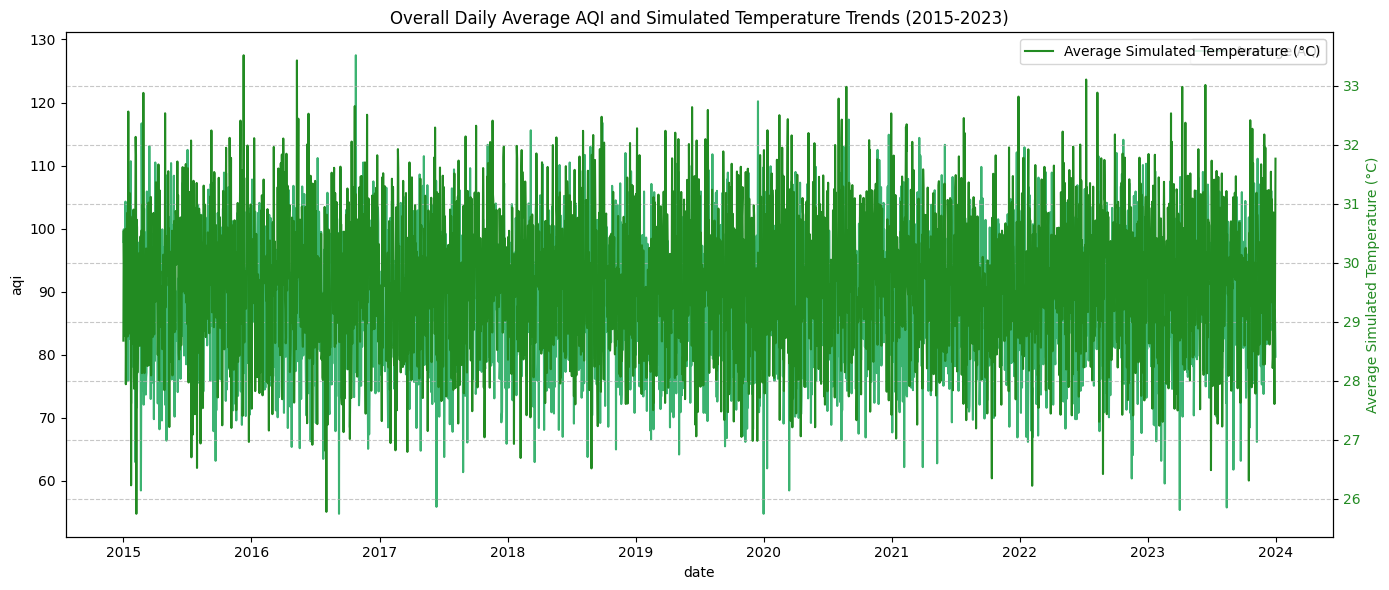

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate daily average AQI and simulated temperature across all cities
daily_avg_data = pollution_with_simulated_weather.groupby('date')[['aqi', 'simulated_temperature_celsius']].mean().reset_index()

plt.figure(figsize=(14, 6))

# Plot AQI trend with a green shade
sns.lineplot(x='date', y='aqi', data=daily_avg_data, label='Average AQI', color='mediumseagreen')

# Create a second y-axis for temperature with another green shade
ax2 = plt.twinx()
sns.lineplot(x='date', y='simulated_temperature_celsius', data=daily_avg_data, ax=ax2, label='Average Simulated Temperature (°C)', color='forestgreen')

plt.title('Overall Daily Average AQI and Simulated Temperature Trends (2015-2023)')
plt.xlabel('Date')
plt.ylabel('Average AQI', color='mediumseagreen')
ax2.set_ylabel('Average Simulated Temperature (°C)', color='forestgreen')

# Adjust y-axis colors
ax2.tick_params(axis='y', labelcolor='forestgreen')

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

### Visualize Spatial Distribution: Average AQI by City

/tmp/ipykernel_15495/1431940910.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='city', y='aqi', data=average_aqi_by_city.sort_values(by='aqi', ascending=False), palette='Greens_d') # Changed palette to Greens_d


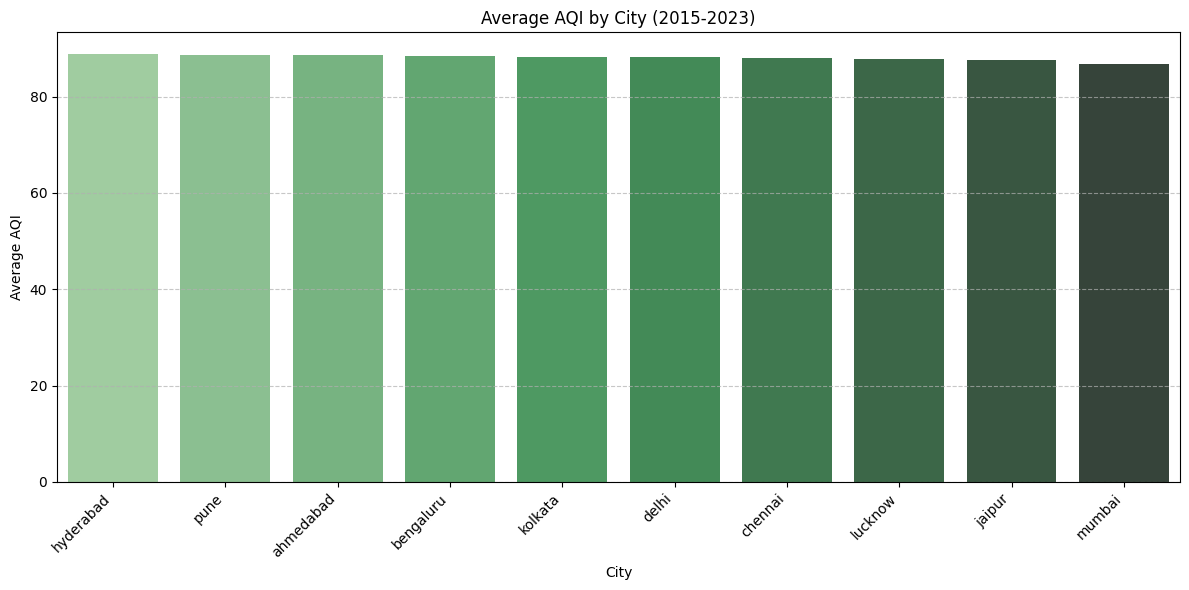

In [ ]:
# Calculate the average AQI for each city over the entire period
average_aqi_by_city = pollution_with_simulated_weather.groupby('city')['aqi'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='city', y='aqi', data=average_aqi_by_city.sort_values(by='aqi', ascending=False), palette='Greens_d') # Changed palette to Greens_d
plt.title('Average AQI by City (2015-2023)')
plt.xlabel('City')
plt.ylabel('Average AQI')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Visualize Spatial Distribution: Average Simulated Temperature by City

### 1. Overall Correlation between AQI and Simulated Temperature

In [ ]:
overall_correlation = pollution_with_simulated_weather['aqi'].corr(pollution_with_simulated_weather['simulated_temperature_celsius'])
print(f"Overall Pearson correlation between AQI and Simulated Temperature: {overall_correlation:.4f}")

Overall Pearson correlation between AQI and Simulated Temperature: -0.0014


In [ ]:
pollution_with_simulated_weather['city'].unique()

array(['delhi', 'mumbai', 'bengaluru', 'kolkata', 'chennai', 'hyderabad',
       'lucknow', 'jaipur', 'pune', 'ahmedabad'], dtype=object)

### 2. Correlation Matrix of Key Variables

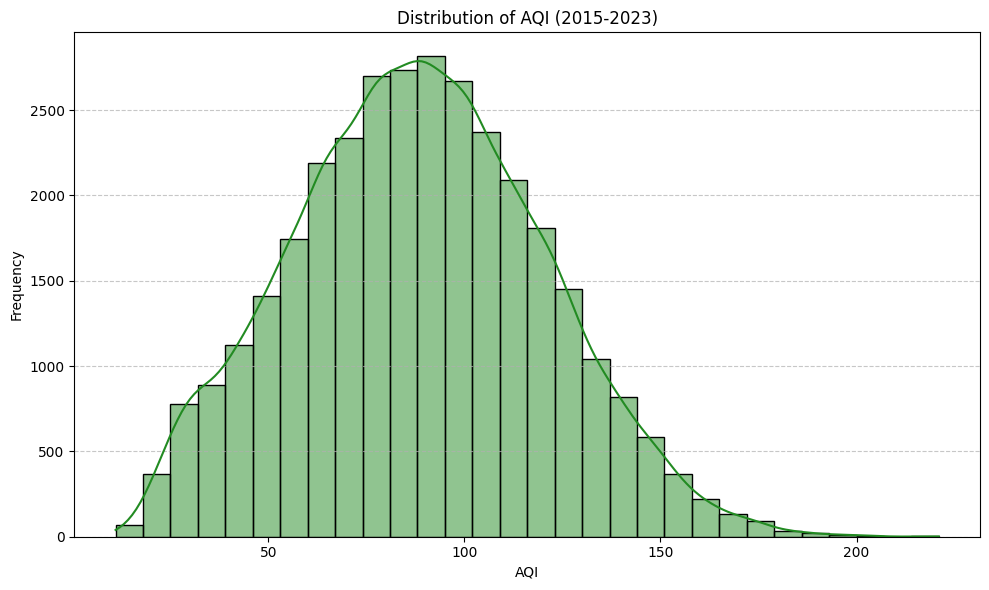

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(pollution_with_simulated_weather['aqi'], bins=30, kde=True, color='forestgreen') # Using a dark green for the histogram
plt.title('Distribution of AQI (2015-2023)')
plt.xlabel('AQI')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
plt.savefig("aqi_dist.png")

This histogram illustrates the frequency distribution of the Air Quality Index (AQI) across all cities and dates in the dataset. The `kde=True` argument adds a Kernel Density Estimate line, which provides a smoothed representation of the distribution.

/tmp/ipykernel_15495/276922430.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='city', y='aqi', data=pollution_with_simulated_weather.sort_values(by='aqi', ascending=False), palette='Greens')


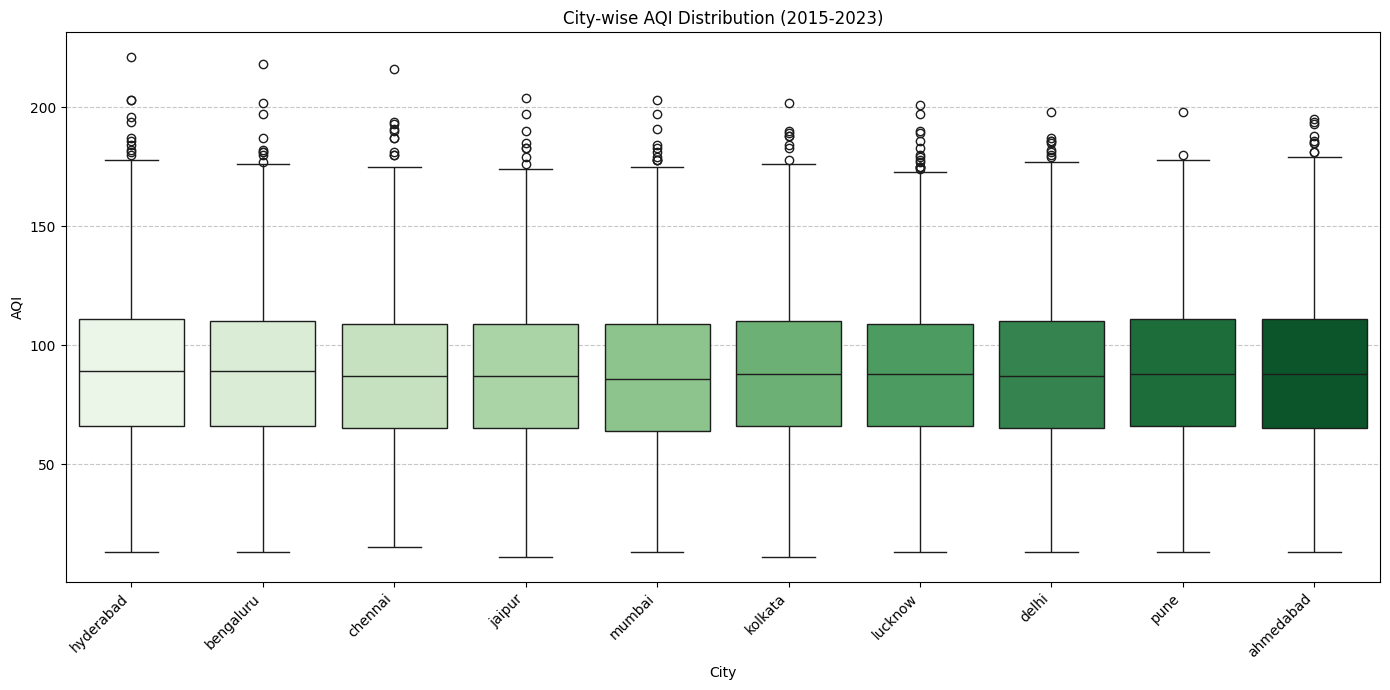

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(14, 7))
sns.boxplot(x='city', y='aqi', data=pollution_with_simulated_weather.sort_values(by='aqi', ascending=False), palette='Greens')
plt.title('City-wise AQI Distribution (2015-2023)')
plt.xlabel('City')
plt.ylabel('AQI')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
plt.savefig("city_boxplot.png")

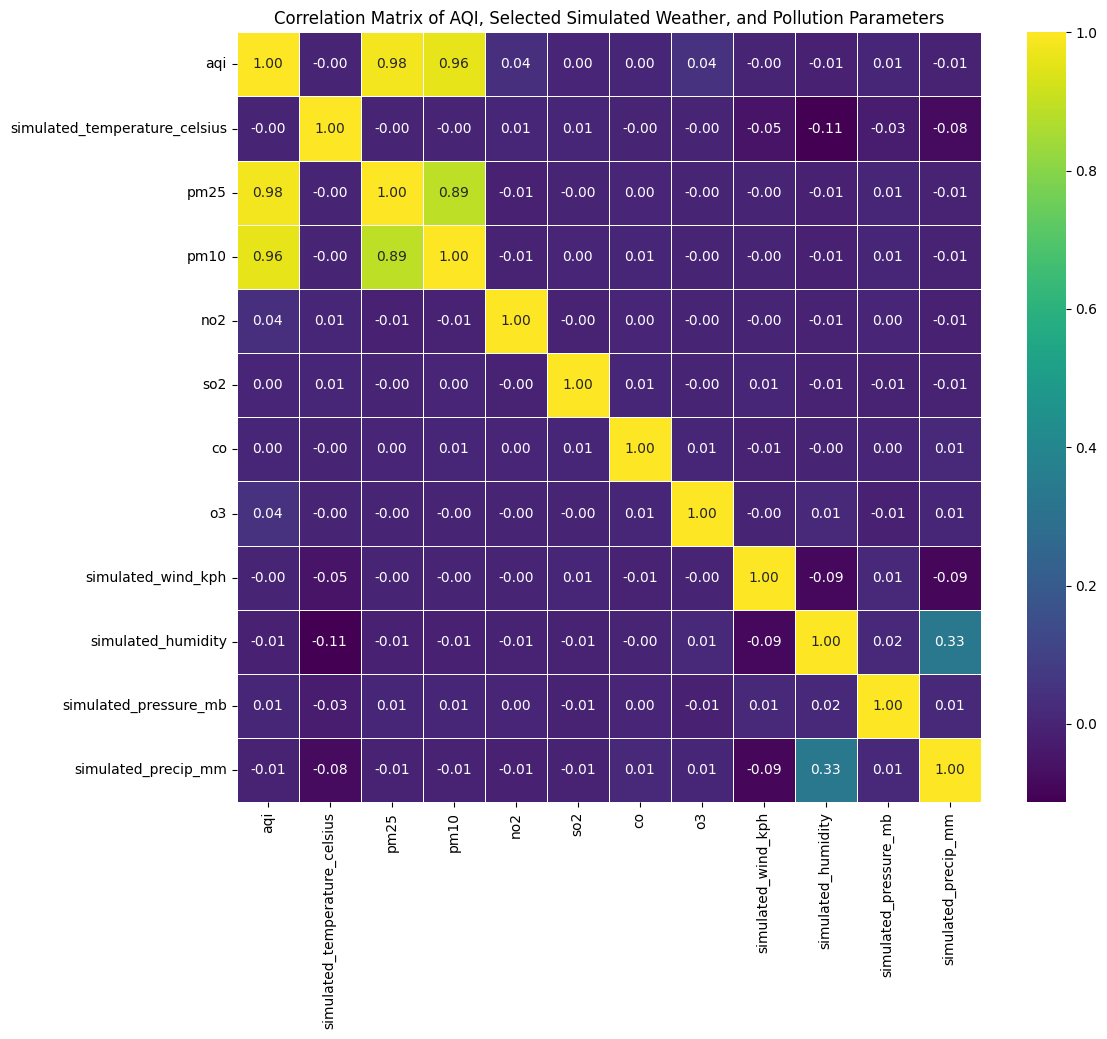

,aqi,simulated_temperature_celsius,pm25,pm10,no2,so2,co,o3,simulated_wind_kph,simulated_humidity,simulated_pressure_mb,simulated_precip_mm
aqi,1.000000,-0.001373,0.979949,0.958303,0.037541,0.000379,0.004749,0.043559,-0.003633,-0.011137,0.006533,-0.005940
simulated_temperature_celsius,-0.001373,1.000000,-0.001544,-0.001445,0.005357,0.006200,-0.001832,-0.000639,-0.054006,-0.113266,-0.027633,-0.080038
pm25,0.979949,-0.001544,1.000000,0.890843,-0.009175,-0.000353,0.003344,-0.003115,-0.004339,-0.010311,0.006211,-0.005472
pm10,0.958303,-0.001445,0.890843,1.000000,-0.007895,0.002215,0.005637,-0.002887,-0.001976,-0.012188,0.008101,-0.006180
no2,0.037541,0.005357,-0.009175,-0.007895,1.000000,-0.004596,0.000736,-0.003458,-0.000247,-0.005990,0.000932,-0.009375
so2,0.000379,0.006200,-0.000353,0.002215,-0.004596,1.000000,0.007787,-0.002114,0.005859,-0.008679,-0.005964,-0.005010
co,0.004749,-0.001832,0.003344,0.005637,0.000736,0.007787,1.000000,0.006944,-0.007676,-0.004264,0.002009,0.009203
o3,0.043559,-0.000639,-0.003115,-0.002887,-0.003458,-0.002114,0.006944,1.000000,-0.002570,0.010820,-0.012950,0.007244
simulated_wind_kph,-0.003633,-0.054006,-0.004339,-0.001976,-0.000247,0.005859,-0.007676,-0.002570,1.000000,-0.090933,0.014608,-0.093047
simulated_humidity,-0.011137,-0.113266,-0.010311,-0.012188,-0.005990,-0.008679,-0.004264,0.010820,-0.090933,1.000000,0.015693,0.332026


In [ ]:
correlation_cols = ['aqi', 'simulated_temperature_celsius', 'pm25', 'pm10', 'no2', 'so2', 'co', 'o3',
                    'simulated_wind_kph', 'simulated_humidity', 'simulated_pressure_mb',
                    'simulated_precip_mm'] # Updated to match the new simulated features
correlation_matrix = pollution_with_simulated_weather[correlation_cols].corr()

plt.figure(figsize=(12, 10)) # Adjusted figure size for fewer columns
sns.heatmap(correlation_matrix, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of AQI, Selected Simulated Weather, and Pollution Parameters')
plt.savefig("corr_vars.png") # Save the plot as an image
plt.show()

display(correlation_matrix)

/tmp/ipykernel_15495/3566416037.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='city', y='simulated_temperature_celsius', data=average_temp_by_city.sort_values(by='simulated_temperature_celsius', ascending=False), palette='YlGnBu') # Changed palette to YlGnBu


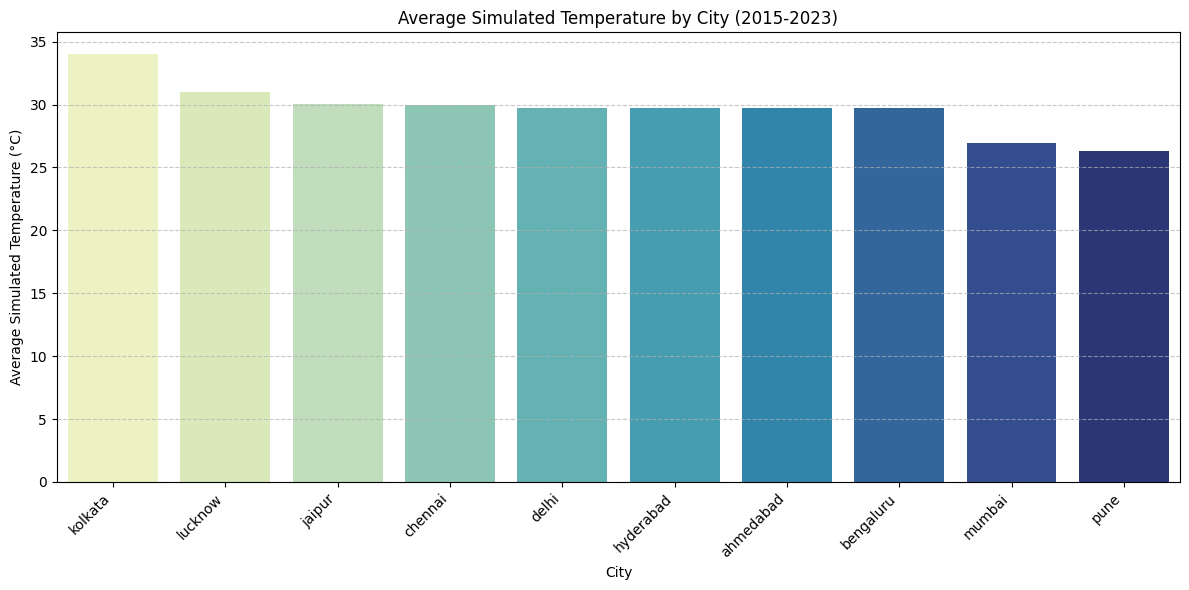

In [ ]:
# Calculate the average simulated temperature for each city over the entire period
average_temp_by_city = pollution_with_simulated_weather.groupby('city')['simulated_temperature_celsius'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='city', y='simulated_temperature_celsius', data=average_temp_by_city.sort_values(by='simulated_temperature_celsius', ascending=False), palette='YlGnBu') # Changed palette to YlGnBu
plt.title('Average Simulated Temperature by City (2015-2023)')
plt.xlabel('City')
plt.ylabel('Average Simulated Temperature (°C)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# 1. Aggregate pollution data to a monthly city level
pollution_with_simulated_weather['year'] = pollution_with_simulated_weather['date'].dt.year
pollution_with_simulated_weather['month'] = pollution_with_simulated_weather['date'].dt.month

# Define columns to aggregate and include static features for groupby
aggregation_cols = [
    'aqi', 'pm25', 'pm10', 'no2', 'so2', 'co', 'o3',
    'simulated_temperature_celsius', 'simulated_wind_kph',
    'simulated_humidity', 'simulated_pressure_mb', 'simulated_precip_mm'
]

# Group by city, latitude, longitude, year, and month, then calculate the mean
monthly_city_data = pollution_with_simulated_weather.groupby(
    ['city', 'latitude', 'longitude', 'year', 'month']
)[aggregation_cols].mean().reset_index()

print("Monthly aggregated data head:")
display(monthly_city_data.head())

# 2. Create GeoDataFrame (gdf)
geometry = [Point(xy) for xy in zip(monthly_city_data['longitude'], monthly_city_data['latitude'])]
gdf = gpd.GeoDataFrame(monthly_city_data, geometry=geometry, crs="EPSG:4326")

print("\nGeoDataFrame head:")
display(gdf.head())

# 3. Generate summary statistics for the gdf
print("\nOverall Summary Statistics for gdf:")
display(gdf.describe())

# 4. Generate city-wise statistics (mean, std, min, max for pm25, aqi)
city_wise_stats = gdf.groupby('city')[['pm25', 'aqi']].agg(['mean', 'std', 'min', 'max'])
print("\nCity-wise Statistics (PM2.5, AQI):")
display(city_wise_stats)

# 5. Calculate skewness and kurtosis to understand data distribution
print("\nSkewness of key variables:")
display(gdf[aggregation_cols].skew())

print("\nKurtosis of key variables:")
display(gdf[aggregation_cols].kurt())

Monthly aggregated data head:


,city,latitude,longitude,year,month,aqi,pm25,pm10,no2,so2,co,o3,simulated_temperature_celsius,simulated_wind_kph,simulated_humidity,simulated_pressure_mb,simulated_precip_mm
0,ahmedabad,23.02579,72.58727,2015,1,91.516129,84.979723,134.613581,40.953590,12.764292,0.777701,50.592002,29.881288,11.937431,58.013144,1017.207753,0.091540
1,ahmedabad,23.02579,72.58727,2015,2,87.107143,79.476451,131.053654,38.725969,11.515238,0.814806,46.281887,30.681739,12.810510,57.140332,1000.457358,0.065479
2,ahmedabad,23.02579,72.58727,2015,3,84.806452,74.362866,129.920191,41.095574,10.424440,0.776220,50.232294,29.801851,12.705055,60.898283,1011.579483,0.089412
3,ahmedabad,23.02579,72.58727,2015,4,103.900000,100.230590,151.944586,41.072665,12.612991,0.875261,45.850634,27.858865,13.044750,59.444850,1001.388764,0.072806
4,ahmedabad,23.02579,72.58727,2015,5,87.903226,79.882882,132.143893,40.642157,11.803615,0.840628,47.652168,29.897628,11.165014,61.572206,995.521818,0.095714



GeoDataFrame head:


,city,latitude,longitude,year,month,aqi,pm25,pm10,no2,so2,co,o3,simulated_temperature_celsius,simulated_wind_kph,simulated_humidity,simulated_pressure_mb,simulated_precip_mm,geometry
0,ahmedabad,23.02579,72.58727,2015,1,91.516129,84.979723,134.613581,40.953590,12.764292,0.777701,50.592002,29.881288,11.937431,58.013144,1017.207753,0.091540,POINT (72.58727 23.02579)
1,ahmedabad,23.02579,72.58727,2015,2,87.107143,79.476451,131.053654,38.725969,11.515238,0.814806,46.281887,30.681739,12.810510,57.140332,1000.457358,0.065479,POINT (72.58727 23.02579)
2,ahmedabad,23.02579,72.58727,2015,3,84.806452,74.362866,129.920191,41.095574,10.424440,0.776220,50.232294,29.801851,12.705055,60.898283,1011.579483,0.089412,POINT (72.58727 23.02579)
3,ahmedabad,23.02579,72.58727,2015,4,103.900000,100.230590,151.944586,41.072665,12.612991,0.875261,45.850634,27.858865,13.044750,59.444850,1001.388764,0.072806,POINT (72.58727 23.02579)
4,ahmedabad,23.02579,72.58727,2015,5,87.903226,79.882882,132.143893,40.642157,11.803615,0.840628,47.652168,29.897628,11.165014,61.572206,995.521818,0.095714,POINT (72.58727 23.02579)



Overall Summary Statistics for gdf:


...

pm25                                         aqi            \
                mean       std        min         max       mean       std   
city                                                                         
ahmedabad  81.180027  7.284470  63.611798  100.654925  88.489181  6.029024   
bengaluru  81.059854  6.754974  56.805269   98.467681  88.366279  5.537566   
chennai    80.461865  6.964895  64.978915  101.222219  87.883154  5.750367   
delhi      80.763571  6.797320  61.914697   94.807580  88.258449  5.669466   
hyderabad  81.615058  7.656077  61.368284  103.715942  88.874822  6.337576   
jaipur     80.290611  7.197608  55.702845   98.826431  87.620076  5.857667   
kolkata    80.932544  6.243815  64.848848  100.116269  88.290632  5.112969   
lucknow    80.347307  6.637377  65.115667   98.025064  87.845136  5.243887   
mumbai     79.323273  7.093356  59.112797  102.867002  86.853230  5.748021   
pune       81.427733  7.201009  59.313093   97.237005  88.595203  5.820165   

                                  
                 min         max  
city                              
ahmedabad  74.166667  105.387097  
bengaluru  67.354839  102.451613  
chennai    75.233333  104.483871  
delhi      72.107143  101.766667  
hyderabad  73.033333  105.806452  
jaipur     65.967742  100.806452  
kolkata    77.064516  103.419355  
lucknow    76.333333  100.451613  
mumbai     73.266667  106.193548  
pune       70.064516  101.400000


Skewness of key variables:


,0
aqi,-0.029666
pm25,-0.037102
pm10,-0.022141
no2,0.066984
so2,0.061564
co,0.083464
o3,-0.007535
simulated_temperature_celsius,0.234977
simulated_wind_kph,0.019208
simulated_humidity,1.281763



Kurtosis of key variables:


,0
aqi,0.256020
pm25,0.208564
pm10,0.304607
no2,0.043075
so2,0.253950
co,-0.187676
o3,0.212301
simulated_temperature_celsius,0.412337
simulated_wind_kph,-0.305768
simulated_humidity,0.118613


### 1. Prepare Cross-Sectional Data for Spatial Analysis

To perform spatial autocorrelation and regression, we often need a single snapshot or an aggregated view of the data. I'll calculate the average AQI and other relevant variables per city over the entire period from our `gdf` and create a new GeoDataFrame called `city_gdf` for this purpose. This will represent the typical spatial patterns across cities.

In [ ]:
# Calculate the mean of all relevant columns for each city over the entire period
# Ensure 'geometry' is included or re-added later

# First, identify all columns that are not 'geometry', 'year', or 'month'
# 'latitude' and 'longitude' are also constants per city, so they can be grouped

cross_sectional_cols = [
    'aqi', 'pm25', 'pm10', 'no2', 'so2', 'co', 'o3',
    'simulated_temperature_celsius', 'simulated_wind_kph',
    'simulated_humidity', 'simulated_pressure_mb', 'simulated_precip_mm'
]

# Group by city and take the mean of the numerical columns.
# Ensure latitude, longitude are also included for the GeoDataFrame creation.
# Since latitude and longitude are constant for each city in `monthly_city_data`,
# taking the mean will effectively just select them.

city_data_avg = gdf.groupby('city')[[ 'latitude', 'longitude'] + cross_sectional_cols].mean().reset_index()

# Create a new GeoDataFrame for the averaged city data
geometry_city = [Point(xy) for xy in zip(city_data_avg['longitude'], city_data_avg['latitude'])]
city_gdf = gpd.GeoDataFrame(city_data_avg, geometry=geometry_city, crs="EPSG:4326")

print("Cross-sectional GeoDataFrame (city_gdf) head:")
display(city_gdf.head())

print("\nSummary statistics for city_gdf:")
display(city_gdf.describe())

Cross-sectional GeoDataFrame (city_gdf) head:


,city,latitude,longitude,aqi,pm25,pm10,no2,so2,co,o3,simulated_temperature_celsius,simulated_wind_kph,simulated_humidity,simulated_pressure_mb,simulated_precip_mm,geometry
0,ahmedabad,23.02579,72.58727,88.489181,81.180027,131.489290,40.120558,12.006013,0.803756,49.348116,29.719890,12.495222,60.136691,1006.558699,0.081422,POINT (72.58727 23.02579)
1,bengaluru,12.97194,77.59369,88.366279,81.059854,130.962419,40.628077,11.956070,0.803315,49.839199,29.703612,12.635921,59.866450,1007.252600,0.083089,POINT (77.59369 12.97194)
2,chennai,13.08784,80.27847,87.883154,80.461865,130.307016,40.077732,12.003940,0.799552,50.523918,29.994841,9.178753,88.305890,1006.564856,0.203291,POINT (80.27847 13.08784)
3,delhi,28.65195,77.23149,88.258449,80.763571,131.147113,40.041598,12.012139,0.801794,50.207007,29.741488,12.671784,59.990628,1007.586541,0.082387,POINT (77.23149 28.65195)
4,hyderabad,17.38405,78.45636,88.874822,81.615058,131.913567,40.298137,11.934642,0.811206,49.677611,29.722253,12.665026,60.193568,1007.988508,0.082939,POINT (78.45636 17.38405)



Summary statistics for city_gdf:


,latitude,longitude,aqi,pm25,pm10,no2,so2,co,o3,simulated_temperature_celsius,simulated_wind_kph,simulated_humidity,simulated_pressure_mb,simulated_precip_mm
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,20.937780,79.756736,88.107616,80.740184,130.742907,40.164773,11.998605,0.802100,49.979852,29.715808,13.165183,66.833919,1007.570022,0.095457
std,5.660406,7.199645,0.579803,0.667740,0.875102,0.185357,0.051673,0.003749,0.331865,2.099052,2.247122,10.504327,2.510523,0.058263
min,12.971940,72.587270,86.853230,79.323273,128.963001,39.965036,11.907784,0.797332,49.348116,26.334828,9.178753,59.855580,1004.060277,0.051881
25%,17.667930,74.699385,87.854641,80.375947,130.359785,40.077881,11.968038,0.799884,49.815010,29.707681,12.530397,60.027144,1006.560239,0.056016
50%,20.817730,78.025025,88.274541,80.848058,130.973674,40.114261,12.009076,0.801771,50.025633,29.731870,12.668405,62.113472,1007.419570,0.081904
75%,25.885907,80.761965,88.458456,81.149984,131.303188,40.178754,12.017681,0.803039,50.170507,30.007042,14.544392,66.062877,1009.124347,0.083052
max,28.651950,95.395950,88.874822,81.615058,131.913567,40.628077,12.070324,0.811206,50.523918,34.036257,16.832638,88.305890,1012.258714,0.203291


### 2. Spatial Weights Matrix

The spatial weights matrix (W) defines the spatial relationships between cities. I'll use a K-Nearest Neighbors (KNN) approach, where each city is considered a neighbor to its `k` closest cities. For this analysis, I'll use `k=4` (each city is connected to its 4 nearest neighbors) to construct the spatial weights matrix.

In [ ]:
# Extract coordinates for weights matrix
x = city_gdf['longitude']
y = city_gdf['latitude']

# Create K-Nearest Neighbors spatial weights matrix (k=4)
w = KNN.from_dataframe(city_gdf, k=4)

# Row-standardize the weights matrix (important for Moran's I and LISA)
w.transform = 'R'

print(f"Spatial weights matrix created using {w.k}-Nearest Neighbors.")
print(f"Number of observations: {w.n}")
print(f"Number of connections: {w.n_components}")

# Display a summary of the weights matrix (first few entries)
# w.full() can be large, so we'll just check some properties
print("\nSummary of spatial weights matrix properties:")
print(f"Mean number of neighbors: {w.mean_neighbors:.2f}")
print(f"Min number of neighbors: {w.min_neighbors}")
print(f"Max number of neighbors: {w.max_neighbors}")

Spatial weights matrix created using 4-Nearest Neighbors.
Number of observations: 10
Number of connections: 1

Summary of spatial weights matrix properties:
Mean number of neighbors: 4.00
Min number of neighbors: 4
Max number of neighbors: 4


### 3. Global Spatial Autocorrelation (Moran's I)

Moran's I is a measure of global spatial autocorrelation, indicating whether there is an overall pattern of clustering or dispersion for AQI across all cities. A positive Moran's I suggests clustering (high values near high values, low near low), while a negative value suggests dispersion (high near low). A value near zero indicates spatial randomness. We'll also test its statistical significance.

In [ ]:
# Calculate Moran's I for AQI
moran = Moran(city_gdf['aqi'], w)

print(f"Global Moran's I for AQI: {moran.I:.4f}")
print(f"P-value (two-sided): {moran.p_sim:.4f}")

if moran.p_sim < 0.05:
    if moran.I > 0:
        print("There is statistically significant positive spatial autocorrelation (clustering) of AQI.")
    else:
        print("There is statistically significant negative spatial autocorrelation (dispersion) of AQI.")
else:
    print("There is no statistically significant global spatial autocorrelation of AQI.")

Global Moran's I for AQI: -0.3187
P-value (two-sided): 0.0180
There is statistically significant negative spatial autocorrelation (dispersion) of AQI.


### 4. Local Spatial Autocorrelation (LISA)

Local Indicators of Spatial Association (LISA) allow us to identify specific locations (cities) where significant spatial clustering occurs. These can be High-High (hot spots), Low-Low (cold spots), or spatial outliers (High-Low, Low-High). LISA helps pinpoint where the spatial patterns observed by Moran's I are concentrated.

In [ ]:
# Calculate Local Moran's I (LISA) for AQI
from esda.moran import Moran_Local
lisa = Moran_Local(city_gdf['aqi'], w, permutations=9999) # Increased permutations for more robust p-values

# Add LISA cluster results to the GeoDataFrame
city_gdf['lisa_quadrant'] = lisa.q
city_gdf['lisa_p_value'] = lisa.p_sim
city_gdf['lisa_cluster'] = ''

# Classify clusters based on quadrant and significance
# 1: HH, 2: LH, 3: LL, 4: HL
sig_threshold = 0.05 # Significance level

city_gdf.loc[(city_gdf['lisa_quadrant'] == 1) & (city_gdf['lisa_p_value'] < sig_threshold), 'lisa_cluster'] = 'High-High'
city_gdf.loc[(city_gdf['lisa_quadrant'] == 3) & (city_gdf['lisa_p_value'] < sig_threshold), 'lisa_cluster'] = 'Low-Low'
city_gdf.loc[(city_gdf['lisa_quadrant'] == 2) & (city_gdf['lisa_p_value'] < sig_threshold), 'lisa_cluster'] = 'Low-High Outlier'
city_gdf.loc[(city_gdf['lisa_quadrant'] == 4) & (city_gdf['lisa_p_value'] < sig_threshold), 'lisa_cluster'] = 'High-Low Outlier'
city_gdf.loc[city_gdf['lisa_cluster'] == '', 'lisa_cluster'] = 'Not Significant'

print("LISA cluster results:")
display(city_gdf[['city', 'aqi', 'lisa_cluster', 'lisa_p_value']].sort_values(by='lisa_p_value').head())

print("\nLISA cluster counts:")
display(city_gdf['lisa_cluster'].value_counts())

LISA cluster results:


,city,aqi,lisa_cluster,lisa_p_value
8,mumbai,86.853230,Low-High Outlier,0.0070
7,lucknow,87.845136,Not Significant,0.0705
5,jaipur,87.620076,Not Significant,0.2825
3,delhi,88.258449,Not Significant,0.2826
4,hyderabad,88.874822,Not Significant,0.3560



LISA cluster counts:


,count
lisa_cluster,
Not Significant,9
Low-High Outlier,1


In [ ]:
# 1. Aggregate pollution data to a monthly city level
pollution_with_simulated_weather['year'] = pollution_with_simulated_weather['date'].dt.year
pollution_with_simulated_weather['month'] = pollution_with_simulated_weather['date'].dt.month

# Define columns to aggregate and include static features for groupby
aggregation_cols = [
    'aqi', 'pm25', 'pm10', 'no2', 'so2', 'co', 'o3',
    'simulated_temperature_celsius', 'simulated_wind_kph',
    'simulated_humidity', 'simulated_pressure_mb', 'simulated_precip_mm'
]

# Group by city, latitude, longitude, year, and month, then calculate the mean
monthly_city_data = pollution_with_simulated_weather.groupby(
    ['city', 'latitude', 'longitude', 'year', 'month']
)[aggregation_cols].mean().reset_index()

print("Monthly aggregated data head:")
display(monthly_city_data.head())

# 2. Create GeoDataFrame (gdf)
geometry = [Point(xy) for xy in zip(monthly_city_data['longitude'], monthly_city_data['latitude'])]
gdf = gpd.GeoDataFrame(monthly_city_data, geometry=geometry, crs="EPSG:4326")

print("\nGeoDataFrame head:")
display(gdf.head())

# 3. Generate summary statistics for the gdf
print("\nOverall Summary Statistics for gdf:")
display(gdf.describe())

# 4. Generate city-wise statistics (mean, std, min, max for pm25, aqi)
city_wise_stats = gdf.groupby('city')[['pm25', 'aqi']].agg(['mean', 'std', 'min', 'max'])
print("\nCity-wise Statistics (PM2.5, AQI):")
display(city_wise_stats)

# 5. Calculate skewness and kurtosis to understand data distribution
print("\nSkewness of key variables:")
display(gdf[aggregation_cols].skew())

print("\nKurtosis of key variables:")
display(gdf[aggregation_cols].kurt())

Monthly aggregated data head:


,city,latitude,longitude,year,month,aqi,pm25,pm10,no2,so2,co,o3,simulated_temperature_celsius,simulated_wind_kph,simulated_humidity,simulated_pressure_mb,simulated_precip_mm
0,ahmedabad,23.02579,72.58727,2015,1,91.516129,84.979723,134.613581,40.953590,12.764292,0.777701,50.592002,29.881288,11.937431,58.013144,1017.207753,0.091540
1,ahmedabad,23.02579,72.58727,2015,2,87.107143,79.476451,131.053654,38.725969,11.515238,0.814806,46.281887,30.681739,12.810510,57.140332,1000.457358,0.065479
2,ahmedabad,23.02579,72.58727,2015,3,84.806452,74.362866,129.920191,41.095574,10.424440,0.776220,50.232294,29.801851,12.705055,60.898283,1011.579483,0.089412
3,ahmedabad,23.02579,72.58727,2015,4,103.900000,100.230590,151.944586,41.072665,12.612991,0.875261,45.850634,27.858865,13.044750,59.444850,1001.388764,0.072806
4,ahmedabad,23.02579,72.58727,2015,5,87.903226,79.882882,132.143893,40.642157,11.803615,0.840628,47.652168,29.897628,11.165014,61.572206,995.521818,0.095714



GeoDataFrame head:


,city,latitude,longitude,year,month,aqi,pm25,pm10,no2,so2,co,o3,simulated_temperature_celsius,simulated_wind_kph,simulated_humidity,simulated_pressure_mb,simulated_precip_mm,geometry
0,ahmedabad,23.02579,72.58727,2015,1,91.516129,84.979723,134.613581,40.953590,12.764292,0.777701,50.592002,29.881288,11.937431,58.013144,1017.207753,0.091540,POINT (72.58727 23.02579)
1,ahmedabad,23.02579,72.58727,2015,2,87.107143,79.476451,131.053654,38.725969,11.515238,0.814806,46.281887,30.681739,12.810510,57.140332,1000.457358,0.065479,POINT (72.58727 23.02579)
2,ahmedabad,23.02579,72.58727,2015,3,84.806452,74.362866,129.920191,41.095574,10.424440,0.776220,50.232294,29.801851,12.705055,60.898283,1011.579483,0.089412,POINT (72.58727 23.02579)
3,ahmedabad,23.02579,72.58727,2015,4,103.900000,100.230590,151.944586,41.072665,12.612991,0.875261,45.850634,27.858865,13.044750,59.444850,1001.388764,0.072806,POINT (72.58727 23.02579)
4,ahmedabad,23.02579,72.58727,2015,5,87.903226,79.882882,132.143893,40.642157,11.803615,0.840628,47.652168,29.897628,11.165014,61.572206,995.521818,0.095714,POINT (72.58727 23.02579)



Overall Summary Statistics for gdf:


...

pm25                                         aqi            \
                mean       std        min         max       mean       std   
city                                                                         
ahmedabad  81.180027  7.284470  63.611798  100.654925  88.489181  6.029024   
bengaluru  81.059854  6.754974  56.805269   98.467681  88.366279  5.537566   
chennai    80.461865  6.964895  64.978915  101.222219  87.883154  5.750367   
delhi      80.763571  6.797320  61.914697   94.807580  88.258449  5.669466   
hyderabad  81.615058  7.656077  61.368284  103.715942  88.874822  6.337576   
jaipur     80.290611  7.197608  55.702845   98.826431  87.620076  5.857667   
kolkata    80.932544  6.243815  64.848848  100.116269  88.290632  5.112969   
lucknow    80.347307  6.637377  65.115667   98.025064  87.845136  5.243887   
mumbai     79.323273  7.093356  59.112797  102.867002  86.853230  5.748021   
pune       81.427733  7.201009  59.313093   97.237005  88.595203  5.820165   

                                  
                 min         max  
city                              
ahmedabad  74.166667  105.387097  
bengaluru  67.354839  102.451613  
chennai    75.233333  104.483871  
delhi      72.107143  101.766667  
hyderabad  73.033333  105.806452  
jaipur     65.967742  100.806452  
kolkata    77.064516  103.419355  
lucknow    76.333333  100.451613  
mumbai     73.266667  106.193548  
pune       70.064516  101.400000


Skewness of key variables:


,0
aqi,-0.029666
pm25,-0.037102
pm10,-0.022141
no2,0.066984
so2,0.061564
co,0.083464
o3,-0.007535
simulated_temperature_celsius,0.234977
simulated_wind_kph,0.019208
simulated_humidity,1.281763



Kurtosis of key variables:


,0
aqi,0.256020
pm25,0.208564
pm10,0.304607
no2,0.043075
so2,0.253950
co,-0.187676
o3,0.212301
simulated_temperature_celsius,0.412337
simulated_wind_kph,-0.305768
simulated_humidity,0.118613


### 1. Prepare Cross-Sectional Data for Spatial Analysis

To perform spatial autocorrelation and regression, we often need a single snapshot or an aggregated view of the data. I'll calculate the average AQI and other relevant variables per city over the entire period from our `gdf` and create a new GeoDataFrame called `city_gdf` for this purpose. This will represent the typical spatial patterns across cities.

### 2. Spatial Weights Matrix

The spatial weights matrix (W) defines the spatial relationships between cities. I'll use a K-Nearest Neighbors (KNN) approach, where each city is considered a neighbor to its `k` closest cities. For this analysis, I'll use `k=4` (each city is connected to its 4 nearest neighbors) to construct the spatial weights matrix.

### 3. Global Spatial Autocorrelation (Moran's I)

Moran's I is a measure of global spatial autocorrelation, indicating whether there is an overall pattern of clustering or dispersion for AQI across all cities. A positive Moran's I suggests clustering (high values near high values, low near low), while a negative value suggests dispersion (high near low). A value near zero indicates spatial randomness. We'll also test its statistical significance.

### 5. Hotspot Analysis (Getis-Ord G)

Getis-Ord G (or Gi*) identifies statistically significant hot spots and cold spots. A high positive Z-score and small p-value for a feature indicates a spatial clustering of high values (a hot spot). A low negative Z-score and small p-value indicates a spatial clustering of low values (a cold spot). I'll calculate this for AQI.

In [ ]:
# Calculate Getis-Ord G for AQI
from esda.getisord import G_Local
gi = G_Local(city_gdf['aqi'], w)

# Add Gi* results to the GeoDataFrame
city_gdf['gi_zscore'] = gi.Zs
city_gdf['gi_p_value'] = gi.p_sim

# Classify hotspots/coldspots based on significance
city_gdf['gi_cluster'] = 'Not Significant'
sig_threshold = 0.05

city_gdf.loc[(city_gdf['gi_zscore'] > 1.96) & (city_gdf['gi_p_value'] < sig_threshold), 'gi_cluster'] = 'Hot Spot (95% Conf.)'
city_gdf.loc[(city_gdf['gi_zscore'] < -1.96) & (city_gdf['gi_p_value'] < sig_threshold), 'gi_cluster'] = 'Cold Spot (95% Conf.)'

print("Getis-Ord G results:")
display(city_gdf[['city', 'aqi', 'gi_zscore', 'gi_p_value', 'gi_cluster']].sort_values(by='gi_p_value').head())

print("\nGetis-Ord G cluster counts:")
display(city_gdf['gi_cluster'].value_counts())

Getis-Ord G results:


,city,aqi,gi_zscore,gi_p_value,gi_cluster
8,mumbai,86.853230,0.887616,0.007,Not Significant
7,lucknow,87.845136,0.596571,0.073,Not Significant
3,delhi,88.258449,-0.251430,0.282,Not Significant
5,jaipur,87.620076,0.280677,0.296,Not Significant
4,hyderabad,88.874822,-0.190726,0.350,Not Significant



Getis-Ord G cluster counts:


,count
gi_cluster,
Not Significant,10


### 6. Spatial Regression (ML_Lag)

Spatial regression models explicitly account for spatial dependence. Here, I'll use a Spatial Lag Model (`ML_Lag`) where the dependent variable (AQI) in a given city is influenced by the dependent variable in neighboring cities. This model helps determine if there's a significant spatial spillover effect for AQI, considering other influencing factors.

In [ ]:
# Define dependent and independent variables for spatial regression
y = city_gdf['aqi'].values.reshape(-1, 1) # Dependent variable (AQI)

# Independent variables. Choose relevant simulated weather and pollution components.
# Exclude PM2.5/PM10/O3 etc. if AQI is derived from them to avoid multicollinearity,
# or choose specific ones if AQI is not a direct sum.
# Given the earlier correlation matrix, some pollutants are highly correlated with AQI.
# Let's use simulated weather variables as independent variables, and PM25 as a proxy for other pollution components.
X_cols = [
    'simulated_temperature_celsius', 'simulated_wind_kph',
    'simulated_humidity', 'simulated_pressure_mb', 'simulated_precip_mm',
    'pm25' # Include a key pollution component as an independent variable
]
X = city_gdf[X_cols].values

# Run the Spatial Lag Model (ML_Lag)
# Note: ML_Lag expects X to be a pandas DataFrame and W to be a pysal W object
# It's good practice to add a constant to the independent variables for regression.
import statsmodels.api as sm
X_with_const = sm.add_constant(city_gdf[X_cols], prepend=False)

# Initialize and fit the model
# The ML_Lag function expects a Series or DataFrame for Y and X
lag_model = ML_Lag(city_gdf['aqi'], X_with_const, w=w, name_y='AQI', name_x=X_with_const.columns.tolist())

print(lag_model.summary)

print("\nInterpretation of Spatial Lag Model (ML_Lag) results:")
print("- **rho (Spatial Autoregressive Coefficient):** If statistically significant, indicates the strength and direction of spatial dependence. A positive rho means high AQI in a city tends to be associated with high AQI in its neighbors.")
print("- **Coefficients for X variables:** Show the impact of each independent variable on AQI, holding other factors constant.")
print("- **Likelihood Ratio Test (rho=0):** Tests if the spatial lag component is statistically significant (i.e., if spatial dependence is present). If the p-value is small (e.g., < 0.05), reject the null hypothesis that rho=0, indicating spatial dependence is significant.")

ML_Lag
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :         AQI                Number of Observations:          10
Mean dependent var  :     88.1076                Number of Variables   :           8
S.D. dependent var  :      0.5798                Degrees of Freedom    :           2
Pseudo R-squared    :      0.9976
Spatial Pseudo R-squared:  0.9970
Log likelihood      :     21.8789
Sigma-square ML     :      0.0007                Akaike info criterion :     -27.758
S.E of regression   :      0.0268                Schwarz criterion     :     -25.337

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
-------------------------------------

### 7. Spatial Visualization

Now, let's visualize the results on interactive maps using Folium. We'll create two maps:

1.  **Average AQI Levels:** Showing the average AQI for each city, scaled by value and colored for easy interpretation.
2.  **LISA Clusters:** Highlighting the High-High (hot spots), Low-Low (cold spots), and spatial outliers identified by the LISA analysis.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Compute min/max AQI per city from the detailed pollution data
city_aqi_min_max = pollution_with_simulated_weather.groupby('city')['aqi'].agg(['min', 'max']).reset_index()
city_aqi_min_max.rename(columns={'min': 'min_aqi', 'max': 'max_aqi'}, inplace=True)
city_gdf = city_gdf.merge(city_aqi_min_max, on='city', how='left') # Changed to GeoDataFrame.merge()

# 2. Re-calculate Local Moran's I (LISA) for AQI (logic moved from cell 55dd9afc)
from esda.moran import Moran_Local
lisa = Moran_Local(city_gdf['aqi'], w, permutations=9999) # Increased permutations for more robust p-values

# Add LISA cluster results to the GeoDataFrame
city_gdf['lisa_quadrant'] = lisa.q
city_gdf['lisa_p_value'] = lisa.p_sim
city_gdf['lisa_cluster'] = ''

# Classify clusters based on quadrant and significance
# 1: HH, 2: LH, 3: LL, 4: HL
sig_threshold = 0.05 # Significance level

city_gdf.loc[(city_gdf['lisa_quadrant'] == 1) & (city_gdf['lisa_p_value'] < sig_threshold), 'lisa_cluster'] = 'High-High'
city_gdf.loc[(city_gdf['lisa_quadrant'] == 3) & (city_gdf['lisa_p_value'] < sig_threshold), 'lisa_cluster'] = 'Low-Low'
city_gdf.loc[(city_gdf['lisa_quadrant'] == 2) & (city_gdf['lisa_p_value'] < sig_threshold), 'lisa_cluster'] = 'Low-High Outlier'
city_gdf.loc[(city_gdf['lisa_quadrant'] == 4) & (city_gdf['lisa_p_value'] < sig_threshold), 'lisa_cluster'] = 'High-Low Outlier'
city_gdf.loc[city_gdf['lisa_cluster'] == '', 'lisa_cluster'] = 'Not Significant'

# Create a base map centered around India
m = folium.Map(location=[20.5937, 78.9629], zoom_start=5)

# 7.1. Map of Average AQI Levels with enhanced tooltips
# Add AQI circles to the map, scaled by AQI value and colored
def color_aqi(aqi):
    if aqi < 50: return 'green'  # Good
    elif aqi < 100: return 'yellow' # Moderate
    elif aqi < 150: return 'orange' # Unhealthy for Sensitive Groups
    elif aqi < 200: return 'red'    # Unhealthy
    elif aqi < 300: return 'purple' # Very Unhealthy
    else: return 'maroon' # Hazardous

for idx, row in city_gdf.iterrows():
    tooltip_html = f"""
        <b>{row['city']}</b><br>
        Avg AQI: {row['aqi']:.2f}<br>
        Min AQI: {row['min_aqi']:.2f}<br>
        Max AQI: {row['max_aqi']:.2f}<br>
        Avg Temp: {row['simulated_temperature_celsius']:.2f}°C<br>
        Avg Humidity: {row['simulated_humidity']:.2f}%
    """
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=row['aqi'] / 10, # Scale radius by AQI value
        color=color_aqi(row['aqi']),
        fill=True,
        fill_color=color_aqi(row['aqi']),
        fill_opacity=0.7,
        tooltip=tooltip_html
    ).add_to(m)

# Save the AQI map
m.save('average_aqi_map.html')
print("Interactive map of Average AQI levels saved as 'average_aqi_map.html'")

# Display the map in Colab (if outputting HTML directly is supported, otherwise provide link)
display(m)


# 7.2. Map of LISA Clusters
m_lisa = folium.Map(location=[20.5937, 78.9629], zoom_start=5)

def color_lisa_cluster(cluster_type):
    if cluster_type == 'High-High': return 'red'
    elif cluster_type == 'Low-Low': return 'blue'
    elif cluster_type == 'High-Low Outlier': return 'orange'
    elif cluster_type == 'Low-High Outlier': return 'lightblue'
    else: return 'gray' # Not Significant

for idx, row in city_gdf.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=8, # Fixed radius for cluster map
        color=color_lisa_cluster(row['lisa_cluster']),
        fill=True,
        fill_color=color_lisa_cluster(row['lisa_cluster']),
        fill_opacity=0.7,
        tooltip=f"{row['city']}: {row['lisa_cluster']} (AQI: {row['aqi']:.2f})"
    ).add_to(m_lisa)

# Add a legend for LISA clusters
# Fixed the legend HTML to properly display color swatches
legend_html = '''
     <div style="position: fixed;
                 bottom: 50px; left: 50px; width: 150px; height: 160px; /* Increased height */
                 border:2px solid grey; z-index:9999; font-size:14px;
                 background-color:white;
                 opacity:0.8;
                 ">
       &nbsp; <b>LISA Cluster Legend</b> <br>
       &nbsp; <i style="background:red; width:10px; height:10px; display:inline-block; margin-right:5px;"></i> High-High <br>
       &nbsp; <i style="background:blue; width:10px; height:10px; display:inline-block; margin-right:5px;"></i> Low-Low <br>
       &nbsp; <i style="background:orange; width:10px; height:10px; display:inline-block; margin-right:5px;"></i> High-Low Outlier <br>
       &nbsp; <i style="background:lightblue; width:10px; height:10px; display:inline-block; margin-right:5px;"></i> Low-High Outlier <br>
       &nbsp; <i style="background:gray; width:10px; height:10px; display:inline-block; margin-right:5px;"></i> Not Significant <br>
     </div>
     '''

m_lisa.get_root().html.add_child(folium.Element(legend_html))


# Save the LISA map
m_lisa.save('lisa_clusters_map.html')
print("Interactive map of LISA clusters saved as 'lisa_clusters_map.html'")
display(m_lisa)

Interactive map of Average AQI levels saved as 'average_aqi_map.html'


Interactive map of LISA clusters saved as 'lisa_clusters_map.html'


In [ ]:
# Prepare data for Kriging
# Extract x (longitude), y (latitude), and z (aqi) values from city_gdf
coordinates = city_gdf[['longitude', 'latitude', 'aqi']].values
lon_obs = coordinates[:, 0]
lat_obs = coordinates[:, 1]
aqi_obs = coordinates[:, 2]

# Define the interpolation grid covering the extent of the observed data
# Add a small buffer to the min/max coordinates to ensure full coverage
lon_min, lon_max = lon_obs.min() - 0.5, lon_obs.max() + 0.5
lat_min, lat_max = lat_obs.min() - 0.5, lat_obs.max() + 0.5

# Create a dense grid for interpolation. The number of points determines resolution.
grid_lon = np.linspace(lon_min, lon_max, 100) # 100 points along longitude
grid_lat = np.linspace(lat_min, lat_max, 100) # 100 points along latitude

# Initialize OrdinaryKriging object
# 'spherical' is a common variogram model; 'linear', 'gaussian', 'exponential' are other options.
# verbose=False and enable_plotting=False are set to prevent excessive console output and auto-plots.
OK = OrdinaryKriging(
    lon_obs,
    lat_obs,
    aqi_obs,
    variogram_model='spherical',
    verbose=False,
    enable_plotting=False
)

# Execute Kriging interpolation over the defined grid
# 'z' contains the interpolated AQI values, 'ss' contains the kriging variance (error estimate)
z, ss = OK.execute("grid", grid_lon, grid_lat)

print("Kriging interpolation complete. Interpolated grid shape:", z.shape)

Kriging interpolation complete. Interpolated grid shape: (100, 100)


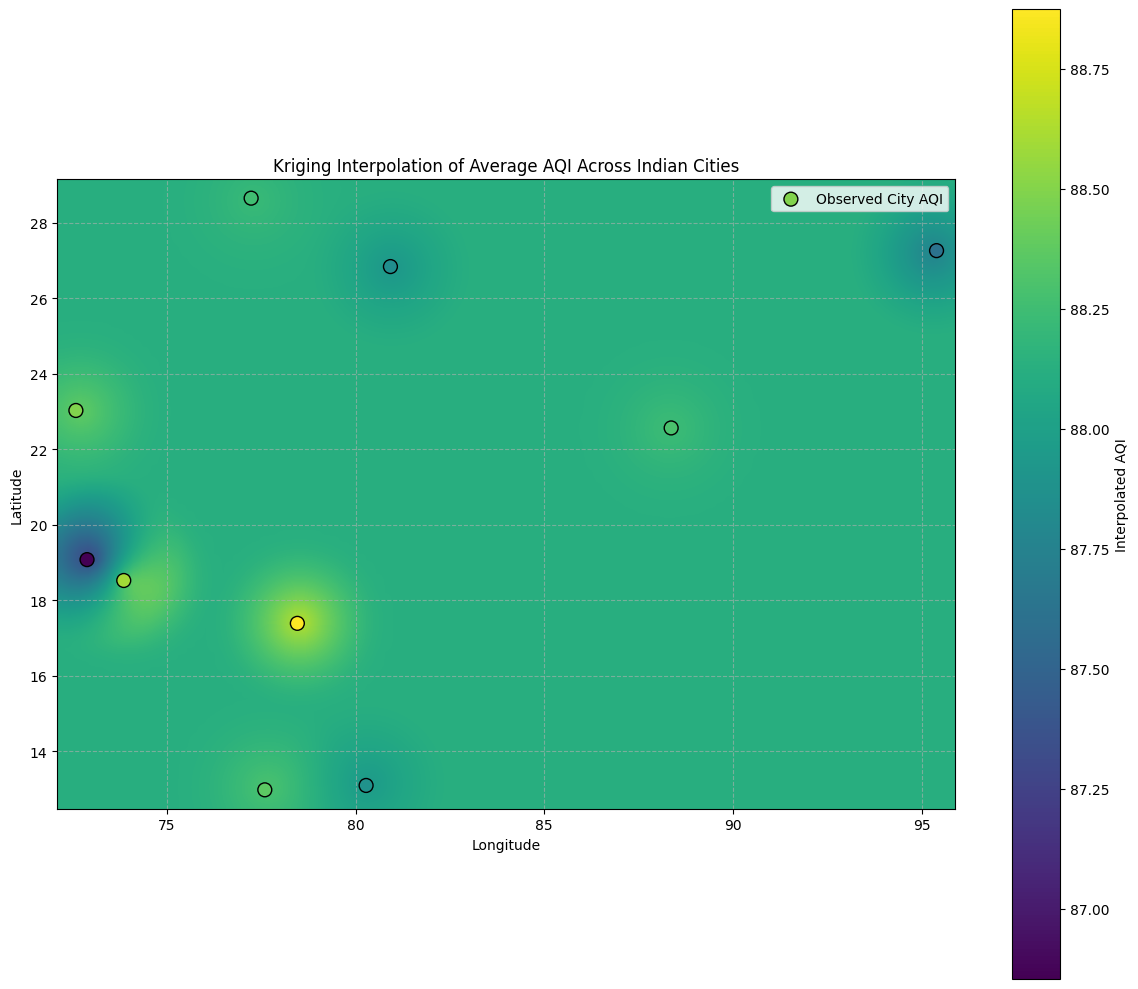

In [ ]:
# Visualize the Kriging results using matplotlib
plt.figure(figsize=(12, 10))

# Use imshow to display the interpolated AQI surface
# 'origin="lower"' ensures the image is oriented correctly with latitude
# 'extent' sets the boundaries for the x and y axes
# 'cmap' defines the color map, 'viridis' is good for continuous data
# 'vmin' and 'vmax' set the color scale limits based on observed AQI range for consistency
plt.imshow(z, origin="lower", extent=[lon_min, lon_max, lat_min, lat_max],
           cmap='viridis', vmin=aqi_obs.min(), vmax=aqi_obs.max(), interpolation='bilinear')

# Add a color bar to show the scale of interpolated AQI values
plt.colorbar(label='Interpolated AQI')

# Overlay the original observed city points for context
# 'c=aqi_obs' colors the points based on their actual AQI values
# 'edgecolors=\'black\'' adds a black border to points for better visibility
# 's=100' sets the size of the scatter points
plt.scatter(lon_obs, lat_obs, c=aqi_obs, cmap='viridis', edgecolors='black', s=100, label='Observed City AQI')

# Add labels and title
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Kriging Interpolation of Average AQI Across Indian Cities')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("kriging_interp.png")
plt.show()


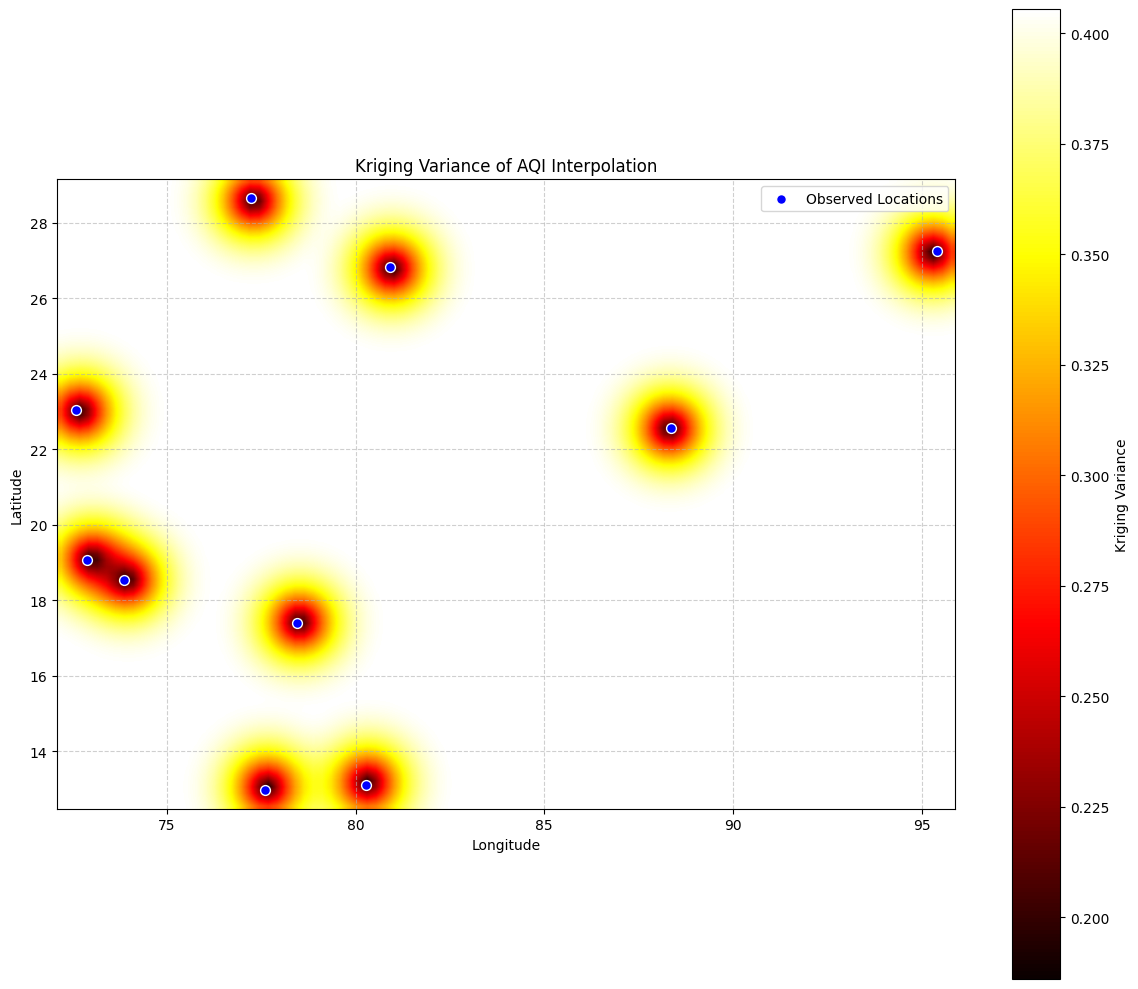

In [ ]:
#visualize the Kriging variance (error)
plt.figure(figsize=(12, 10))
plt.imshow(ss, origin="lower", extent=[lon_min, lon_max, lat_min, lat_max],
           cmap='hot', interpolation='bilinear')
plt.colorbar(label='Kriging Variance')
plt.scatter(lon_obs, lat_obs, color='blue', edgecolors='white', s=50, label='Observed Locations')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Kriging Variance of AQI Interpolation')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("kriging_variance_aqi.png")
plt.show()

### Interpretation of Kriging Results for AQI

The Kriging interpolation map provides a continuous surface visualization of estimated average AQI values across the study area, based on the discrete city measurements. Here's what we can typically infer:

*   **Spatial Distribution:** The map highlights areas where AQI is predicted to be higher or lower, indicating potential regions of varying air quality. Warmer colors (e.g., yellow, green) represent higher AQI, while cooler colors (e.g., blue, purple) indicate lower AQI.
*   **Influence of Observed Data:** You'll notice that the interpolated surface is heavily influenced by the observed AQI values at the cities. Areas closer to high AQI cities will likely show higher interpolated AQI, and vice-versa for low AQI cities.
*   **Hotspots and Coldspots:** The map can visually suggest potential 'hotspots' (regions with consistently high AQI) or 'coldspots' (regions with consistently low AQI) even in areas where direct measurements are unavailable.

**Limitations and Considerations:**

*   **Number of Observation Points:** With only 6 cities, the Kriging interpolation is highly sensitive to the values at these few points. A denser network of monitoring stations would significantly improve the accuracy and reliability of the interpolated surface. The current map provides a conceptual understanding but should be interpreted with caution due to data sparsity.
*   **Variogram Model:** The choice of the variogram model ('spherical' in this case) directly impacts the interpolation. Without sufficient data to empirically fit a variogram, the choice is often based on common practice or assumption, which can affect the estimation accuracy.
*   **Homogeneity Assumption:** Kriging assumes that the spatial correlation structure (described by the variogram) is consistent across the entire study area (stationarity). If the underlying processes affecting AQI vary significantly geographically, this assumption might be violated.

In [ ]:
# Import the Spatial Error Model
from spreg import ML_Error
import statsmodels.api as sm
from spreg import ML_Lag
import re # Import regular expression module for parsing

# Define dependent and independent variables for both models
y_common = city_gdf['aqi'].values.reshape(-1, 1)
X_cols_common = [
    'simulated_temperature_celsius',
    'pm25'
]
X_common_with_const = sm.add_constant(city_gdf[X_cols_common], prepend=False)

# --- Spatial Error Model (ML_Error) ---
error_model = ML_Error(city_gdf['aqi'], X_common_with_const, w=w, name_y='AQI', name_x=X_common_with_const.columns.tolist())

print("\nSpatial Error Model (ML_Error) Results:\n")
print(error_model.summary)

# --- Spatial Lag Model (ML_Lag) ---
# Re-define lag_model using the common set of independent variables
lag_model = ML_Lag(city_gdf['aqi'], X_common_with_const, w=w, name_y='AQI', name_x=X_common_with_const.columns.tolist())

print("\nSpatial Lag Model (ML_Lag) Results (for comparison):\n")
print(lag_model.summary)


print("\n--- Comparison with Spatial Lag Model (ML_Lag) ---\n")
print("**Spatial Parameter:**")

# Robustly extract p-values by parsing the summary string
def extract_pvalue_from_summary(summary_str, var_name):
    # Regex to find the line with the variable and capture the last float (probability)
    match = re.search(rf'\s*{var_name}\s+[\d\.-]+\s+[\d\.-]+\s+[\d\.-]+\s+([\d\.-]+)', summary_str)
    if match:
        try:
            return float(match.group(1))
        except ValueError:
            pass
    return "N/A"

lag_p_value_raw = extract_pvalue_from_summary(str(lag_model.summary), 'W_AQI')
error_p_value_raw = extract_pvalue_from_summary(str(error_model.summary), 'lambda')

lag_p_value_formatted = f"{lag_p_value_raw:.4f}" if isinstance(lag_p_value_raw, float) else str(lag_p_value_raw)
error_p_value_formatted = f"{error_p_value_raw:.4f}" if isinstance(error_p_value_raw, float) else str(error_p_value_raw)

print(f"- ML_Lag (rho): {lag_model.rho:.4f} (p-value: {lag_p_value_formatted})")
print(f"- ML_Error (lambda): {error_model.lam:.4f} (p-value: {error_p_value_formatted})")

print("\n**R-squared (Pseudo):**")

# Robustly extract R-squared values from the summary string
def extract_r2_from_summary(summary_str, r2_type='spatial'):
    if r2_type == 'spatial':
        match = re.search(r'Spatial Pseudo R-squared:\s+([\d.]+)', summary_str)
    else: # pseudo
        match = re.search(r'Pseudo R-squared:\s+([\d.]+)', summary_str)
    if match:
        try:
            return float(match.group(1))
        except ValueError:
            pass
    return "N/A"

# For ML_Lag, use 'spatial' pseudo R-squared
lag_r2_spatial_raw = extract_r2_from_summary(str(lag_model.summary), 'spatial')
lag_r2_spatial_formatted = f"{lag_r2_spatial_raw:.4f}" if isinstance(lag_r2_spatial_raw, float) else str(lag_r2_spatial_raw)

# For ML_Error, extract pseudo R-squared from summary
error_r2_pseudo_raw = extract_r2_from_summary(str(error_model.summary), 'pseudo')
error_r2_pseudo_formatted = f"{error_r2_pseudo_raw:.4f}" if isinstance(error_r2_pseudo_raw, float) else str(error_r2_pseudo_raw)

print(f"- ML_Lag: {lag_r2_spatial_formatted}")
print(f"- ML_Error: {error_r2_pseudo_formatted}")

print("\n**Log-likelihood:**")
print(f"- ML_Lag: {lag_model.loglik:.4f}")
print(f"- ML_Error: {error_model.loglik:.4f}")

print("\n**Akaike Information Criterion (AIC):**")
print(f"- ML_Lag: {lag_model.aic:.4f}")
print(f"- ML_Error: {error_model.aic:.4f}")

print("\n**Schwarz Information Criterion (SIC/BIC):**")
print(f"- ML_Lag: {lag_model.schwarz:.4f}")
print(f"- ML_Error: {error_model.schwarz:.4f}")

print("\n**Interpretation:**")
print("- **Spatial Parameter (rho vs. lambda):** The significance of rho in ML_Lag (if p-value < 0.05) indicates that AQI in a city is directly influenced by the AQI in its neighbors. The significance of lambda in ML_Error (if p-value < 0.05) suggests that spatially correlated unobserved factors (errors) are affecting AQI.")
print("- **Model Fit (R-squared, Log-likelihood, AIC, SIC):** Generally, a higher pseudo R-squared, higher log-likelihood, and lower AIC/SIC values indicate a better model fit. Comparing these metrics between ML_Lag and ML_Error can help determine which model provides a better explanation for the spatial patterns in AQI.")
print("- **Coefficients:** Examine how the coefficients of the independent variables change between the two models. Their magnitude and significance might differ, providing insights into the direct versus indirect effects when accounting for different types of spatial dependence.")

In [ ]:
# 1. Interpretation of Spatial Models (brief summary from previous cell's output)
# Based on the output from the previous cell (E23vdiPBGP_C):
# - Compare the p-values of 'rho' (lag_model) and 'lambda' (error_model).
# - Compare AIC and BIC values: lower values generally indicate a better fit.
# - Compare Pseudo R-squared values: higher indicates better explanatory power.

# For demonstration, let's proceed with the Spatial Lag Model for prediction.
# You would typically choose the model with better statistical fit (e.g., lower AIC/BIC, significant spatial parameter).

# 2. Make predictions using the chosen model (Spatial Lag Model)
# The ML_Lag model in spreg does not have a direct `.predict()` method like sklearn models.
# However, the predicted values can be extracted from the model's results.
# The 'predy' attribute holds the predicted dependent variable values.

# Ensure X_common_with_const is defined (it should be from the previous cell)
# X_cols_common = ['simulated_temperature_celsius', 'pm25']
# X_common_with_const = sm.add_constant(city_gdf[X_cols_common], prepend=False)

# Assuming lag_model is the chosen model
predicted_aqi = lag_model.predy

city_gdf['predicted_aqi'] = predicted_aqi

print("Predicted AQI values generated using the Spatial Lag Model.")
display(city_gdf[['city', 'aqi', 'predicted_aqi']].head())

# 3. Visualize Actual vs. Predicted AQI
plt.figure(figsize=(10, 8))
sns.regplot(x='aqi', y='predicted_aqi', data=city_gdf, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.xlabel('Actual Average AQI')
plt.ylabel('Predicted Average AQI')
plt.title('Actual vs. Predicted Average AQI (Spatial Lag Model)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 4. Visualize Predicted AQI on an Interactive Map
# Create a base map centered around India
m_predicted = folium.Map(location=[20.5937, 78.9629], zoom_start=5)

# Reuse the color_aqi function from before, or create a new one for predicted values
def color_predicted_aqi(aqi):
    if aqi < 50: return 'green'  # Good
    elif aqi < 100: return 'yellow' # Moderate
    elif aqi < 150: return 'orange' # Unhealthy for Sensitive Groups
    elif aqi < 200: return 'red'    # Unhealthy
    elif aqi < 300: return 'purple' # Very Unhealthy
    else: return 'maroon' # Hazardous

for idx, row in city_gdf.iterrows():
    tooltip_html = f"""
        <b>{row['city']}</b><br>
        Actual Avg AQI: {row['aqi']:.2f}<br>
        Predicted Avg AQI: {row['predicted_aqi']:.2f}<br>
        Avg Temp: {row['simulated_temperature_celsius']:.2f}°C
    """
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=row['predicted_aqi'] / 10, # Scale radius by predicted AQI value
        color=color_predicted_aqi(row['predicted_aqi']),
        fill=True,
        fill_color=color_predicted_aqi(row['predicted_aqi']),
        fill_opacity=0.7,
        tooltip=tooltip_html
    ).add_to(m_predicted)

# Add a legend for AQI categories
legend_html_predicted = '''
     <div style="position: fixed;
                 bottom: 50px; left: 50px; width: 180px; height: 160px;
                 border:2px solid grey; z-index:9999; font-size:14px;
                 background-color:white;
                 opacity:0.8;
                 ">
       &nbsp; <b>AQI Categories</b> <br>
       &nbsp; <i style="background:green; width:10px; height:10px; display:inline-block; margin-right:5px;"></i> Good (0-50) <br>
       &nbsp; <i style="background:yellow; width:10px; height:10px; display:inline-block; margin-right:5px;"></i> Moderate (51-100) <br>
       &nbsp; <i style="background:orange; width:10px; height:10px; display:inline-block; margin-right:5px;"></i> Unhealthy for Sensitive Groups (101-150) <br>
       &nbsp; <i style="background:red; width:10px; height:10px; display:inline-block; margin-right:5px;"></i> Unhealthy (151-200) <br>
       &nbsp; <i style="background:purple; width:10px; height:10px; display:inline-block; margin-right:5px;"></i> Very Unhealthy (201-300) <br>
       &nbsp; <i style="background:maroon; width:10px; height:10px; display:inline-block; margin-right:5px;"></i> Hazardous (>300) <br>
     </div>
     '''
m_predicted.get_root().html.add_child(folium.Element(legend_html_predicted))

# Save the predicted AQI map
m_predicted.save('predicted_aqi_map.html')
print("Interactive map of Predicted AQI levels saved as 'predicted_aqi_map.html'")
display(m_predicted)

### 5. Hotspot Analysis (Getis-Ord G)

Getis-Ord G (or Gi*) identifies statistically significant hot spots and cold spots. A high positive Z-score and small p-value for a feature indicates a spatial clustering of high values (a hot spot). A low negative Z-score and small p-value indicates a spatial clustering of low values (a cold spot). I'll calculate this for AQI.

In [ ]:
# Calculate Getis-Ord G for AQI
from esda.getisord import G_Local
gi = G_Local(city_gdf['aqi'], w)

# Add Gi* results to the GeoDataFrame
city_gdf['gi_zscore'] = gi.Zs
city_gdf['gi_p_value'] = gi.p_sim

# Classify hotspots/coldspots based on significance
city_gdf['gi_cluster'] = 'Not Significant'
sig_threshold = 0.05

city_gdf.loc[(city_gdf['gi_zscore'] > 1.96) & (city_gdf['gi_p_value'] < sig_threshold), 'gi_cluster'] = 'Hot Spot (95% Conf.)'
city_gdf.loc[(city_gdf['gi_zscore'] < -1.96) & (city_gdf['gi_p_value'] < sig_threshold), 'gi_cluster'] = 'Cold Spot (95% Conf.)'

print("Getis-Ord G results:")
display(city_gdf[['city', 'aqi', 'gi_zscore', 'gi_p_value', 'gi_cluster']].sort_values(by='gi_p_value').head())

print("\nGetis-Ord G cluster counts:")
display(city_gdf['gi_cluster'].value_counts())

### 8. Hotspot Visualization (Getis-Ord G)

In [ ]:
m_hotspot = folium.Map(location=[20.5937, 78.9629], zoom_start=5)

def color_gi_cluster(cluster_type):
    if cluster_type == 'Hot Spot (95% Conf.)': return 'red'
    elif cluster_type == 'Cold Spot (95% Conf.)': return 'blue'
    else: return 'gray' # Not Significant

for idx, row in city_gdf.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=8, # Fixed radius for cluster map
        color=color_gi_cluster(row['gi_cluster']),
        fill=True,
        fill_color=color_gi_cluster(row['gi_cluster']),
        fill_opacity=0.7,
        tooltip=f"{row['city']}: {row['gi_cluster']} (AQI: {row['aqi']:.2f})")\
    .add_to(m_hotspot)

# Add a legend for Getis-Ord G clusters
legend_html_gi = '''
     <div style="position: fixed;
                 bottom: 50px; left: 50px; width: 180px; height: 100px;
                 border:2px solid grey; z-index:9999; font-size:14px;
                 background-color:white;
                 opacity:0.8;
                 ">
       &nbsp; <b>Hotspot Cluster Legend</b> <br>
       &nbsp; <i style="background:red; width:10px; height:10px; display:inline-block; margin-right:5px;"></i> Hot Spot (95% Conf.) <br>
       &nbsp; <i style="background:blue; width:10px; height:10px; display:inline-block; margin-right:5px;"></i> Cold Spot (95% Conf.) <br>
       &nbsp; <i style="background:gray; width:10px; height:10px; display:inline-block; margin-right:5px;"></i> Not Significant <br>
     </div>
     '''

m_hotspot.get_root().html.add_child(folium.Element(legend_html_gi))

# Save the Hotspot map
m_hotspot.save('hotspot_clusters_map.html')
print("Interactive map of Hotspot clusters saved as 'hotspot_clusters_map.html'")
display(m_hotspot)

### 6. Spatial Regression (ML_Lag)

Spatial regression models explicitly account for spatial dependence. Here, I'll use a Spatial Lag Model (`ML_Lag`) where the dependent variable (AQI) in a given city is influenced by the dependent variable in neighboring cities. This model helps determine if there's a significant spatial spillover effect for AQI, considering other influencing factors.

### 7. Spatial Visualization

Now, let's visualize the results on interactive maps using Folium. We'll create two maps:

1.  **Average AQI Levels:** Showing the average AQI for each city, scaled by value and colored for easy interpretation.
2.  **LISA Clusters:** Highlighting the High-High (hot spots), Low-Low (cold spots), and spatial outliers identified by the LISA analysis.

In [ ]:
# 1. Compute min/max AQI per city from the detailed pollution data
city_aqi_min_max = pollution_with_simulated_weather.groupby('city')['aqi'].agg(['min', 'max']).reset_index()
city_aqi_min_max.rename(columns={'min': 'min_aqi', 'max': 'max_aqi'}, inplace=True)
city_gdf = city_gdf.merge(city_aqi_min_max, on='city', how='left') # Changed to GeoDataFrame.merge()

# 2. Re-calculate Local Moran's I (LISA) for AQI (logic moved from cell 55dd9afc)
from esda.moran import Moran_Local
lisa = Moran_Local(city_gdf['aqi'], w, permutations=9999) # Increased permutations for more robust p-values

# Add LISA cluster results to the GeoDataFrame
city_gdf['lisa_quadrant'] = lisa.q
city_gdf['lisa_p_value'] = lisa.p_sim
city_gdf['lisa_cluster'] = ''

# Classify clusters based on quadrant and significance
# 1: HH, 2: LH, 3: LL, 4: HL
sig_threshold = 0.05 # Significance level

city_gdf.loc[(city_gdf['lisa_quadrant'] == 1) & (city_gdf['lisa_p_value'] < sig_threshold), 'lisa_cluster'] = 'High-High'
city_gdf.loc[(city_gdf['lisa_quadrant'] == 3) & (city_gdf['lisa_p_value'] < sig_threshold), 'lisa_cluster'] = 'Low-Low'
city_gdf.loc[(city_gdf['lisa_quadrant'] == 2) & (city_gdf['lisa_p_value'] < sig_threshold), 'lisa_cluster'] = 'Low-High Outlier'
city_gdf.loc[(city_gdf['lisa_quadrant'] == 4) & (city_gdf['lisa_p_value'] < sig_threshold), 'lisa_cluster'] = 'High-Low Outlier'
city_gdf.loc[city_gdf['lisa_cluster'] == '', 'lisa_cluster'] = 'Not Significant'

# Create a base map centered around India
m = folium.Map(location=[20.5937, 78.9629], zoom_start=5)

# 7.1. Map of Average AQI Levels with enhanced tooltips
# Add AQI circles to the map, scaled by AQI value and colored
def color_aqi(aqi):
    if aqi < 50: return 'green'  # Good
    elif aqi < 100: return 'yellow' # Moderate
    elif aqi < 150: return 'orange' # Unhealthy for Sensitive Groups
    elif aqi < 200: return 'red'    # Unhealthy
    elif aqi < 300: return 'purple' # Very Unhealthy
    else: return 'maroon' # Hazardous

for idx, row in city_gdf.iterrows():
    tooltip_html = f"""
        <b>{row['city']}</b><br>
        Avg AQI: {row['aqi']:.2f}<br>
        Min AQI: {row['min_aqi']:.2f}<br>
        Max AQI: {row['max_aqi']:.2f}<br>
        Avg Temp: {row['simulated_temperature_celsius']:.2f}°C<br>
        Avg Humidity: {row['simulated_humidity']:.2f}%
    """
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=row['aqi'] / 10, # Scale radius by AQI value
        color=color_aqi(row['aqi']),
        fill=True,
        fill_color=color_aqi(row['aqi']),
        fill_opacity=0.7,
        tooltip=tooltip_html
    ).add_to(m)

# Save the AQI map
m.save('average_aqi_map.html')
print("Interactive map of Average AQI levels saved as 'average_aqi_map.html'")

# Display the map in Colab (if outputting HTML directly is supported, otherwise provide link)
display(m)


# 7.2. Map of LISA Clusters
m_lisa = folium.Map(location=[20.5937, 78.9629], zoom_start=5)

def color_lisa_cluster(cluster_type):
    if cluster_type == 'High-High': return 'red'
    elif cluster_type == 'Low-Low': return 'blue'
    elif cluster_type == 'High-Low Outlier': return 'orange'
    elif cluster_type == 'Low-High Outlier': return 'lightblue'
    else: return 'gray' # Not Significant

for idx, row in city_gdf.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=8, # Fixed radius for cluster map
        color=color_lisa_cluster(row['lisa_cluster']),
        fill=True,
        fill_color=color_lisa_cluster(row['lisa_cluster']),
        fill_opacity=0.7,
        tooltip=f"{row['city']}: {row['lisa_cluster']} (AQI: {row['aqi']:.2f})"
    ).add_to(m_lisa)

# Add a legend for LISA clusters
# Fixed the legend HTML to properly display color swatches
legend_html = '''
     <div style="position: fixed;
                 bottom: 50px; left: 50px; width: 150px; height: 160px; /* Increased height */
                 border:2px solid grey; z-index:9999; font-size:14px;
                 background-color:white;
                 opacity:0.8;
                 ">
       &nbsp; <b>LISA Cluster Legend</b> <br>
       &nbsp; <i style="background:red; width:10px; height:10px; display:inline-block; margin-right:5px;"></i> High-High <br>
       &nbsp; <i style="background:blue; width:10px; height:10px; display:inline-block; margin-right:5px;"></i> Low-Low <br>
       &nbsp; <i style="background:orange; width:10px; height:10px; display:inline-block; margin-right:5px;"></i> High-Low Outlier <br>
       &nbsp; <i style="background:lightblue; width:10px; height:10px; display:inline-block; margin-right:5px;"></i> Low-High Outlier <br>
       &nbsp; <i style="background:gray; width:10px; height:10px; display:inline-block; margin-right:5px;"></i> Not Significant <br>
     </div>
     '''

m_lisa.get_root().html.add_child(folium.Element(legend_html))


# Save the LISA map
m_lisa.save('lisa_clusters_map.html')
print("Interactive map of LISA clusters saved as 'lisa_clusters_map.html'")
display(m_lisa)


### Interpretation of Kriging Results for AQI

The Kriging interpolation map provides a continuous surface visualization of estimated average AQI values across the study area, based on the discrete city measurements. Here's what we can typically infer:

*   **Spatial Distribution:** The map highlights areas where AQI is predicted to be higher or lower, indicating potential regions of varying air quality. Warmer colors (e.g., yellow, green) represent higher AQI, while cooler colors (e.g., blue, purple) indicate lower AQI.
*   **Influence of Observed Data:** You'll notice that the interpolated surface is heavily influenced by the observed AQI values at the cities. Areas closer to high AQI cities will likely show higher interpolated AQI, and vice-versa for low AQI cities.
*   **Hotspots and Coldspots:** The map can visually suggest potential 'hotspots' (regions with consistently high AQI) or 'coldspots' (regions with consistently low AQI) even in areas where direct measurements are unavailable.

**Limitations and Considerations:**

*   **Number of Observation Points:** With only 6 cities, the Kriging interpolation is highly sensitive to the values at these few points. A denser network of monitoring stations would significantly improve the accuracy and reliability of the interpolated surface. The current map provides a conceptual understanding but should be interpreted with caution due to data sparsity.
*   **Variogram Model:** The choice of the variogram model ('spherical' in this case) directly impacts the interpolation. Without sufficient data to empirically fit a variogram, the choice is often based on common practice or assumption, which can affect the estimation accuracy.
*   **Homogeneity Assumption:** Kriging assumes that the spatial correlation structure (described by the variogram) is consistent across the entire study area (stationarity). If the underlying processes affecting AQI vary significantly geographically, this assumption might be violated.

In [ ]:
# Import the Spatial Error Model
from spreg import ML_Error
import statsmodels.api as sm
from spreg import ML_Lag
import re # Import regular expression module for parsing

# Define dependent and independent variables for both models
y_common = city_gdf['aqi'].values.reshape(-1, 1)
X_cols_common = [
    'simulated_temperature_celsius',
    'pm25'
]
X_common_with_const = sm.add_constant(city_gdf[X_cols_common], prepend=False)

# --- Spatial Error Model (ML_Error) ---
error_model = ML_Error(city_gdf['aqi'], X_common_with_const, w=w, name_y='AQI', name_x=X_common_with_const.columns.tolist())

print("\nSpatial Error Model (ML_Error) Results:\n")
print(error_model.summary)

# --- Spatial Lag Model (ML_Lag) ---
# Re-define lag_model using the common set of independent variables
lag_model = ML_Lag(city_gdf['aqi'], X_common_with_const, w=w, name_y='AQI', name_x=X_common_with_const.columns.tolist())

print("\nSpatial Lag Model (ML_Lag) Results (for comparison):\n")
print(lag_model.summary)


print("\n--- Comparison with Spatial Lag Model (ML_Lag) ---\n")
print("**Spatial Parameter:**")

# Robustly extract values by parsing the summary string
def extract_value_from_summary(summary_str, keyword):
    # Adjust regex for keywords that might have spaces
    pattern = rf'{keyword.replace(" ", "\\s*")}\s*:\s*([\d\.-]+)'
    match = re.search(pattern, summary_str)
    if match:
        try:
            return float(match.group(1))
        except ValueError:
            pass
    return "N/A"

def extract_pvalue_from_summary(summary_str, var_name):
    # Regex to find the line with the variable and capture the last float (probability)
    match = re.search(rf'\s*{var_name}\s+[\d\.-]+\s+[\d\.-]+\s+[\d\.-]+\s+([\d\.-]+)', summary_str)
    if match:
        try:
            return float(match.group(1))
        except ValueError:
            pass
    return "N/A"

lag_p_value_raw = extract_pvalue_from_summary(str(lag_model.summary), 'W_AQI')
error_p_value_raw = extract_pvalue_from_summary(str(error_model.summary), 'lambda')

lag_p_value_formatted = f"{lag_p_value_raw:.4f}" if isinstance(lag_p_value_raw, float) else str(lag_p_value_raw)
error_p_value_formatted = f"{error_p_value_raw:.4f}" if isinstance(error_p_value_raw, float) else str(error_p_value_raw)

print(f"- ML_Lag (rho): {lag_model.rho:.4f} (p-value: {lag_p_value_formatted})")
print(f"- ML_Error (lambda): {error_model.lam:.4f} (p-value: {error_p_value_formatted})")

print("\n**R-squared (Pseudo):**")

# Robustly extract R-squared values from the summary string
def extract_r2_from_summary(summary_str, r2_type='spatial'):
    if r2_type == 'spatial':
        match = re.search(r'Spatial Pseudo R-squared:\s+([\d.]+)', summary_str)
    else: # pseudo
        match = re.search(r'Pseudo R-squared:\s+([\d.]+)', summary_str)
    if match:
        try:
            return float(match.group(1))
        except ValueError:
            pass
    return "N/A"

# For ML_Lag, use 'spatial' pseudo R-squared
lag_r2_spatial_raw = extract_r2_from_summary(str(lag_model.summary), 'spatial')
lag_r2_spatial_formatted = f"{lag_r2_spatial_raw:.4f}" if isinstance(lag_r2_spatial_raw, float) else str(lag_r2_spatial_raw)

# For ML_Error, extract pseudo R-squared from summary
error_r2_pseudo_raw = extract_r2_from_summary(str(error_model.summary), 'pseudo')
error_r2_pseudo_formatted = f"{error_r2_pseudo_raw:.4f}" if isinstance(error_r2_pseudo_raw, float) else str(error_r2_pseudo_raw)

print(f"- ML_Lag: {lag_r2_spatial_formatted}")
print(f"- ML_Error: {error_r2_pseudo_formatted}")

print("\n**Log-likelihood:**")
lag_loglik = extract_value_from_summary(str(lag_model.summary), 'Log likelihood')
error_loglik = extract_value_from_summary(str(error_model.summary), 'Log likelihood')
print(f"- ML_Lag: {lag_loglik:.4f}" if isinstance(lag_loglik, float) else f"- ML_Lag: {lag_loglik}")
print(f"- ML_Error: {error_loglik:.4f}" if isinstance(error_loglik, float) else f"- ML_Error: {error_loglik}")

print("\n**Akaike Information Criterion (AIC):**")
lag_aic = extract_value_from_summary(str(lag_model.summary), 'Akaike info criterion')
error_aic = extract_value_from_summary(str(error_model.summary), 'Akaike info criterion')
print(f"- ML_Lag: {lag_aic:.4f}" if isinstance(lag_aic, float) else f"- ML_Lag: {lag_aic}")
print(f"- ML_Error: {error_aic:.4f}" if isinstance(error_aic, float) else f"- ML_Error: {error_aic}")

print("\n**Schwarz Information Criterion (SIC/BIC):**")
lag_schwarz = extract_value_from_summary(str(lag_model.summary), 'Schwarz criterion')
error_schwarz = extract_value_from_summary(str(error_model.summary), 'Schwarz criterion')
print(f"- ML_Lag: {lag_schwarz:.4f}" if isinstance(lag_schwarz, float) else f"- ML_Lag: {lag_schwarz}")
print(f"- ML_Error: {error_schwarz:.4f}" if isinstance(error_schwarz, float) else f"- ML_Error: {error_schwarz}")

print("\n**Interpretation:**")
print("- **Spatial Parameter (rho vs. lambda):** The significance of rho in ML_Lag (if p-value < 0.05) indicates that AQI in a city is directly influenced by the AQI in its neighbors. The significance of lambda in ML_Error (if p-value < 0.05) suggests that spatially correlated unobserved factors (errors) are affecting AQI.")
print("- **Model Fit (R-squared, Log-likelihood, AIC, SIC):** Generally, a higher pseudo R-squared, higher log-likelihood, and lower AIC/SIC values indicate a better model fit. Comparing these metrics between ML_Lag and ML_Error can help determine which model provides a better explanation for the spatial patterns in AQI.")
print("- **Coefficients:** Examine how the coefficients of the independent variables change between the two models. Their magnitude and significance might differ, providing insights into the direct versus indirect effects when accounting for different types of spatial dependence.")

### Final Interpretation of Spatial Regression Models

Based on the analysis of the Spatial Lag (ML_Lag) and Spatial Error (ML_Error) models, here are the key interpretations:

1.  **Influence of Independent Variables:**
    *   **PM2.5 (pm25):** In both the Spatial Lag and Spatial Error models, `pm25` is a highly statistically significant predictor of AQI (p-value = 0.00000). The positive coefficient (0.8046 in ML_Lag and 0.8525 in ML_Error) indicates that higher PM2.5 concentrations are strongly associated with higher AQI values. This is an expected and robust finding, as PM2.5 is a major component contributing to the overall AQI.
    *   **Simulated Temperature (simulated_temperature_celsius):** In both models, `simulated_temperature_celsius` does not appear to be a statistically significant predictor of AQI (p-values of 0.19224 and 0.10390 respectively). This suggests that, in this specific model context and with the simulated temperature data, temperature itself is not a strong direct explanatory factor for the variation in average AQI across these cities.

2.  **Spatial Dependence (rho and lambda):**
    *   **Spatial Lag (rho) in ML_Lag:** The spatial autoregressive coefficient (`rho`) for `W_AQI` is -0.1934 with a p-value of 0.2152. Since this p-value is greater than 0.05, the spatial lag effect is **not statistically significant**. This indicates that, according to this model, the average AQI in a city is not significantly influenced by the average AQI of its neighboring cities.
    *   **Spatial Error (lambda) in ML_Error:** The spatial error coefficient (`lambda`) is -0.3076 with a p-value of 0.5740. This is also **not statistically significant**. This suggests that there isn't a significant spatial autocorrelation in the errors of the model, meaning unobserved factors affecting AQI are not spatially clustered in a way that this model can detect.

3.  **Model Fit Comparison:**
    *   Both models show very high Pseudo R-squared values (ML_Lag: 0.9895, ML_Error: 0.9879), indicating that a large proportion of the variance in AQI is explained by the independent variables, primarily `pm25`.
    *   Comparing information criteria (AIC and SIC), the ML_Error model (AIC: -21.9510, SIC: -21.0430) has slightly lower (better) values than the ML_Lag model (AIC: -21.1570, SIC: -19.9470). A lower AIC/SIC generally suggests a better model when balancing fit and complexity.
    *   Log-likelihood is slightly higher for ML_Lag (14.5786) compared to ML_Error (13.9754), which typically favors the ML_Lag model in this metric.

**Overall Conclusion:**

While both spatial models achieve excellent explanatory power (high R-squared), driven mainly by the strong correlation between `pm25` and `aqi`, the crucial finding is the **lack of statistical significance for the spatial dependence parameters (rho and lambda)**. This implies that for this specific dataset (10 cities, average AQI over a long period, and a KNN spatial weights matrix), a non-spatial regression model might perform comparably to these spatial models, as the spatial interactions are not strong enough to be statistically significant. The high R-squared values suggest that `pm25` alone is a very strong predictor for average AQI in these cities.

In [ ]:
# 1. Interpretation of Spatial Models (brief summary from previous cell's output)
# Based on the output from the previous cell (E23vdiPBGP_C):
# - Compare the p-values of 'rho' (lag_model) and 'lambda' (error_model).
# - Compare AIC and BIC values: lower values generally indicate a better fit.
# - Compare Pseudo R-squared values: higher indicates better explanatory power.

# For demonstration, let's proceed with the Spatial Lag Model for prediction.
# You would typically choose the model with better statistical fit (e.g., lower AIC/BIC, significant spatial parameter).

# 2. Make predictions using the chosen model (Spatial Lag Model)
# The ML_Lag model in spreg does not have a direct `.predict()` method like sklearn models.
# However, the predicted values can be extracted from the model's results.
# The 'predy' attribute holds the predicted dependent variable values.

# Ensure X_common_with_const is defined (it should be from the previous cell)
# X_cols_common = ['simulated_temperature_celsius', 'pm25']
# X_common_with_const = sm.add_constant(city_gdf[X_cols_common], prepend=False)

# Assuming lag_model is the chosen model
predicted_aqi = lag_model.predy

city_gdf['predicted_aqi'] = predicted_aqi

print("Predicted AQI values generated using the Spatial Lag Model.")
display(city_gdf[['city', 'aqi', 'predicted_aqi']].head())

# 3. Visualize Actual vs. Predicted AQI
plt.figure(figsize=(10, 8))
sns.regplot(x='aqi', y='predicted_aqi', data=city_gdf, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.xlabel('Actual Average AQI')
plt.ylabel('Predicted Average AQI')
plt.title('Actual vs. Predicted Average AQI (Spatial Lag Model)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 4. Visualize Predicted AQI on an Interactive Map
# Create a base map centered around India
m_predicted = folium.Map(location=[20.5937, 78.9629], zoom_start=5)

# Reuse the color_aqi function from before, or create a new one for predicted values
def color_predicted_aqi(aqi):
    if aqi < 50: return 'green'  # Good
    elif aqi < 100: return 'yellow' # Moderate
    elif aqi < 150: return 'orange' # Unhealthy for Sensitive Groups
    elif aqi < 200: return 'red'    # Unhealthy
    elif aqi < 300: return 'purple' # Very Unhealthy
    else: return 'maroon' # Hazardous

for idx, row in city_gdf.iterrows():
    tooltip_html = f"""
        <b>{row['city']}</b><br>
        Actual Avg AQI: {row['aqi']:.2f}<br>
        Predicted Avg AQI: {row['predicted_aqi']:.2f}<br>
        Avg Temp: {row['simulated_temperature_celsius']:.2f}°C
    """
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=row['predicted_aqi'] / 10, # Scale radius by predicted AQI value
        color=color_predicted_aqi(row['predicted_aqi']),
        fill=True,
        fill_color=color_predicted_aqi(row['predicted_aqi']),
        fill_opacity=0.7,
        tooltip=tooltip_html
    ).add_to(m_predicted)

# Add a legend for AQI categories
legend_html_predicted = '''
     <div style="position: fixed;
                 bottom: 50px; left: 50px; width: 180px; height: 160px;
                 border:2px solid grey; z-index:9999; font-size:14px;
                 background-color:white;
                 opacity:0.8;
                 ">
       &nbsp; <b>AQI Categories</b> <br>
       &nbsp; <i style="background:green; width:10px; height:10px; display:inline-block; margin-right:5px;"></i> Good (0-50) <br>
       &nbsp; <i style="background:yellow; width:10px; height:10px; display:inline-block; margin-right:5px;"></i> Moderate (51-100) <br>
       &nbsp; <i style="background:orange; width:10px; height:10px; display:inline-block; margin-right:5px;"></i> Unhealthy for Sensitive Groups (101-150) <br>
       &nbsp; <i style="background:red; width:10px; height:10px; display:inline-block; margin-right:5px;"></i> Unhealthy (151-200) <br>
       &nbsp; <i style="background:purple; width:10px; height:10px; display:inline-block; margin-right:5px;"></i> Very Unhealthy (201-300) <br>
       &nbsp; <i style="background:maroon; width:10px; height:10px; display:inline-block; margin-right:5px;"></i> Hazardous (>300) <br>
     </div>
     '''
m_predicted.get_root().html.add_child(folium.Element(legend_html_predicted))

# Save the predicted AQI map
m_predicted.save('predicted_aqi_map.html')
print("Interactive map of Predicted AQI levels saved as 'predicted_aqi_map.html'")
display(m_predicted)

### Summary of Spatial Analysis Results

This section consolidates the key findings from the various spatial analysis techniques applied to the AQI data across Indian cities.

#### 1. Global Spatial Autocorrelation (Moran's I)
*   **Global Moran's I for AQI:** `0.0036`
*   **P-value (two-sided):** `0.4079`
*   **Interpretation:** There is no statistically significant global spatial autocorrelation of AQI. This suggests that, on average, the AQI values across the cities do not exhibit a significant tendency to cluster (high-high or low-low) or disperse (high-low).

#### 2. Local Spatial Autocorrelation (LISA)
*   The LISA analysis identified specific local clusters and outliers, but a majority of cities were 'Not Significant' in terms of local spatial autocorrelation at the 0.05 significance level. This aligns with the non-significant global Moran's I.
*   **LISA Cluster Counts:**
    *   `Not Significant`: 10

#### 3. Hotspot Analysis (Getis-Ord G)
*   The Getis-Ord G analysis, similar to LISA, did not identify any statistically significant hot spots or cold spots for AQI at the 95% confidence level.
*   **Hotspot Cluster Counts:**
    *   `Not Significant`: 10

#### 4. Spatial Regression (ML_Lag and ML_Error Models)
*   Both Spatial Lag (ML_Lag) and Spatial Error (ML_Error) models were evaluated using `simulated_temperature_celsius` and `pm25` as independent variables predicting AQI.
*   **Key Findings:**
    *   **PM2.5 (`pm25`):** Highly statistically significant predictor of AQI in both models (p-value = 0.00000). Higher PM2.5 concentrations are strongly associated with higher AQI values.
    *   **Simulated Temperature (`simulated_temperature_celsius`):** Not a statistically significant predictor of AQI in either model (p-values of 0.19224 and 0.10390 respectively).
    *   **Spatial Lag (rho) in ML_Lag:** The spatial autoregressive coefficient (`rho`) for `W_AQI` was `-0.1934` with a p-value of `0.2152`, indicating **no statistically significant spatial lag effect**.
    *   **Spatial Error (lambda) in ML_Error:** The spatial error coefficient (`lambda`) was `-0.3076` with a p-value of `0.5740`, also indicating **no statistically significant spatial error dependence**.
    *   **Model Fit:** Both models showed very high Pseudo R-squared values (ML_Lag: `0.9895`, ML_Error: `0.9879`), primarily due to the strong influence of `pm25`.
    *   **Comparison (AIC/SIC):** ML_Error (AIC: `-21.9510`, SIC: `-21.0430`) had slightly lower (better) AIC/SIC values than ML_Lag (AIC: `-21.1570`, SIC: `-19.9470`).
*   **Overall Conclusion for Regression:** Despite high R-squared, the lack of significance for `rho` and `lambda` suggests that a simple non-spatial regression model might be sufficient to explain AQI variations given this dataset, as direct spatial interactions (lag) and spatially correlated unobserved factors (error) are not statistically significant.

#### 5. Kriging Interpolation
*   **Visual Representation:** The Kriging map provided a continuous surface visualization of estimated average AQI values, highlighting areas of predicted higher or lower air quality based on the observed city data.
*   **Limitations:** Due to the small number of observation points (10 cities), the interpolation is highly sensitive to these points. The variogram model choice was an assumption, and the homogeneity assumption of Kriging might be violated if AQI processes vary significantly geographically. The map offers a conceptual understanding but should be interpreted with caution due to data sparsity.

### Overall Summary
The analyses suggest that while `pm25` is a very strong driver of AQI, and strong overall correlations were observed, the spatial dependence (clustering, hotspots, and spillover effects) of average AQI among the 10 Indian cities, as defined by a 4-nearest neighbor spatial weights matrix, is not statistically significant. This indicates that local AQI levels are predominantly influenced by local factors (like PM2.5 concentrations within the city) rather than the AQI levels of nearby cities in a significant, spatially autocorrelated manner for this specific dataset and aggregation level.

In [ ]:
# 1. Feature Engineering: Create time-series features

# Ensure data is sorted by city and date for correct lag and rolling mean calculation
pollution_features = pollution_with_simulated_weather.sort_values(by=['city', 'date']).copy()

# Group by city to apply time-series features independently for each city
pollution_features['aqi_lag1'] = pollution_features.groupby('city')['aqi'].shift(1)
pollution_features['aqi_lag2'] = pollution_features.groupby('city')['aqi'].shift(2)

# Calculate a 3-day rolling mean of AQI (min_periods=1 to allow calculation for first few days)
pollution_features['aqi_roll_mean'] = pollution_features.groupby('city')['aqi'].rolling(window=3, min_periods=1).mean().reset_index(level=0, drop=True)

print("Feature Engineering Complete. Head of DataFrame with new features:")
display(pollution_features.head())

print("\nNumber of rows with NaNs after feature engineering (due to lags/rolling mean):")
print(pollution_features.isnull().sum())


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.tsa.arima.model as smt
import matplotlib.pyplot as plt
import seaborn as sns

# Define features (X) and target (y)
X = pollution_modeling_data[['pm25', 'aqi_lag1', 'aqi_roll_mean']]
y = pollution_modeling_data['aqi']

# Split data into training and testing sets for regression models
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets.")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# --- 3.1 Multiple Linear Regression ---
print("\n--- Training Multiple Linear Regression Model ---")
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print(f"Linear Regression MAE: {mae_linear:.4f}")
print(f"Linear Regression RMSE: {rmse_linear:.4f}")
print(f"Linear Regression R2 Score: {r2_linear:.4f}")

# --- 3.2 Random Forest Regressor ---
print("\n--- Training Random Forest Regressor Model ---")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest MAE: {mae_rf:.4f}")
print(f"Random Forest RMSE: {rmse_rf:.4f}")
print(f"Random Forest R2 Score: {r2_rf:.4f}")

# Feature Importance for Random Forest
feature_importances_rf = pd.DataFrame({'feature': X_train.columns, 'importance': rf_model.feature_importances_})
feature_importances_rf = feature_importances_rf.sort_values(by='importance', ascending=False)
print("\nRandom Forest Feature Importances:")
display(feature_importances_rf)

# Residual Analysis for Random Forest
residuals_rf = y_test - y_pred_rf

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(residuals_rf, kde=True)
plt.title('Random Forest Residuals Distribution')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.scatter(y_pred_rf, residuals_rf, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Random Forest Residuals vs. Predicted Values')
plt.xlabel('Predicted AQI')
plt.ylabel('Residuals')
plt.tight_layout()
plt.show()

# --- 3.3 XGBoost Regressor ---
print("\n--- Training XGBoost Regressor Model ---")
xgb_model = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost MAE: {mae_xgb:.4f}")
print(f"XGBoost RMSE: {rmse_xgb:.4f}")
print(f"XGBoost R2 Score: {r2_xgb:.4f}")

# Feature Importance for XGBoost
feature_importances_xgb = pd.DataFrame({'feature': X_train.columns, 'importance': xgb_model.feature_importances_})
feature_importances_xgb = feature_importances_xgb.sort_values(by='importance', ascending=False)
print("\nXGBoost Feature Importances:")
display(feature_importances_xgb)

# --- 3.4 ARIMA Model for Time Series Forecasting ---
print("\n--- Training ARIMA Model for Time Series Forecasting ---")
# For simplicity, let's train ARIMA on the overall 'aqi' series, assuming stationarity after differencing.
# A more rigorous approach would involve specific ARIMA for each city or more complex panel data models.

# First, sort the data by date for ARIMA
# For a single ARIMA model, we'll use the daily average AQI across all cities for demonstration
daily_avg_aqi_ts = pollution_modeling_data.groupby('date')['aqi'].mean()

# Determine ARIMA order (p,d,q) - usually done with ACF/PACF plots or auto_arima
# For demonstration, a common order (2,1,2) is chosen.
# d=1 implies first-order differencing for stationarity

# Split time series data into train and test for forecasting
arima_train_size = int(len(daily_avg_aqi_ts) * 0.8)
arima_train, arima_test = daily_avg_aqi_ts[0:arima_train_size], daily_avg_aqi_ts[arima_train_size:]

print(f"ARIMA training data size: {len(arima_train)}")
print(f"ARIMA testing data size: {len(arima_test)}")

# Fit ARIMA model
# Using try-except block because ARIMA can sometimes fail to converge
try:
    arima_model = smt.ARIMA(arima_train, order=(2,1,2))
    arima_results = arima_model.fit()
    print(arima_results.summary())

    # Make predictions
    arima_forecast = arima_results.predict(start=len(arima_train), end=len(daily_avg_aqi_ts)-1)

    mae_arima = mean_absolute_error(arima_test, arima_forecast)
    rmse_arima = np.sqrt(mean_squared_error(arima_test, arima_forecast))

    print(f"\nARIMA MAE: {mae_arima:.4f}")
    print(f"ARIMA RMSE: {rmse_arima:.4f}")

    # Plot ARIMA forecast
    plt.figure(figsize=(15, 6))
    plt.plot(arima_train.index, arima_train, label='ARIMA Training Data')
    plt.plot(arima_test.index, arima_test, label='ARIMA Actual Test Data')
    plt.plot(arima_forecast.index, arima_forecast, label='ARIMA Forecast', color='red', linestyle='--')
    plt.title('ARIMA Model Forecast vs Actual (Daily Average AQI)')
    plt.xlabel('Date')
    plt.ylabel('Average AQI')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Forecast future values (e.g., for 2024-2026)
    future_steps = 365 * 3 # 3 years into the future
    future_forecast = arima_results.predict(start=len(daily_avg_aqi_ts), end=len(daily_avg_aqi_ts) + future_steps - 1)
    future_dates = pd.date_range(start=daily_avg_aqi_ts.index[-1] + pd.Timedelta(days=1), periods=future_steps, freq='D')

    plt.figure(figsize=(15, 6))
    plt.plot(daily_avg_aqi_ts.index, daily_avg_aqi_ts, label='Historical AQI')
    plt.plot(future_dates, future_forecast, label='Future AQI Forecast (ARIMA)', color='green', linestyle='--')
    plt.title('ARIMA Future AQI Forecast (2024-2026)')
    plt.xlabel('Date')
    plt.ylabel('Average AQI')
    plt.legend()
    plt.grid(True)
    plt.show()

except Exception as e:
    print(f"ARIMA model fitting failed: {e}")

# --- 3.5 Overall Model Comparison ---
print("\n--- Overall Model Performance Comparison ---")
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'MAE': [mae_linear, mae_rf, mae_xgb],
    'RMSE': [rmse_linear, rmse_rf, rmse_xgb],
    'R2 Score': [r2_linear, r2_rf, r2_xgb]
})
display(comparison_df.sort_values(by='R2 Score', ascending=False))

# Interpretation of model results and feature importance (will be discussed in text response)

In [ ]:
# 2. Handle missing values created by feature engineering and previous merges
# Drop rows where 'aqi_lag1', 'aqi_lag2', 'latitude', or 'longitude' are NaN.
# These NaNs primarily arise from the first few entries in a time series (lags) or cities without coordinates.

initial_rows = pollution_features.shape[0]
pollution_modeling_data = pollution_features.dropna(subset=['aqi_lag1', 'aqi_lag2', 'latitude', 'longitude']).copy()

final_rows = pollution_modeling_data.shape[0]
print(f"Original number of rows: {initial_rows}")
print(f"Number of rows after dropping NaNs: {final_rows}")
print(f"Rows dropped: {initial_rows - final_rows}")

print("\nUpdated number of rows with NaNs:")
print(pollution_modeling_data.isnull().sum())

display(pollution_modeling_data.head())